In [2]:
# Import Libraries
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score,
                             roc_curve, auc)
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight

# XGBoost
try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print("XGBoost not installed; XGB model will be skipped.")

# Time-Series
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Prophet
try:
    from prophet import Prophet
    PROPHET_AVAILABLE = True
except ImportError:
    PROPHET_AVAILABLE = False
    print("Prophet not installed; Prophet model will be skipped.")

# Evaluation
from sklearn.metrics import mean_absolute_error
from math import sqrt

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi']  = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
PALETTE = sns.color_palette('tab10')

print("All libraries loaded successfully.")


Importing plotly failed. Interactive plots will not work.


All libraries loaded successfully.


In [3]:
# Load the pre-merged dataset 
DATA_PATH = "merged_air_crash_data.csv"

df_raw = pd.read_csv(DATA_PATH, low_memory=False)

print(f"Dataset shape : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"Memory usage  : {df_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB")


Dataset shape : 29,708 rows × 50 columns
Memory usage  : 57.5 MB


In [4]:
# Column inventory 
pd.set_option('display.max_rows', 60)
info = pd.DataFrame({
    'dtype'    : df_raw.dtypes,
    'non_null' : df_raw.notnull().sum(),
    'null_%'   : (df_raw.isnull().mean() * 100).round(1)
})
print(info.to_string())


                          dtype  non_null  null_%
ev_id                       str     29708     0.0
ev_type                     str     29708     0.0
ev_date                     str     29708     0.0
ev_city                     str     29692     0.1
ev_state                    str     25057    15.7
ev_country                  str     29704     0.0
wx_cond_basic               str     24804    16.5
light_cond                  str     24474    17.6
sky_cond_nonceil            str     20410    31.3
sky_ceil_ht             float64     29536     0.6
vis_sm                  float64     23254    21.7
wind_dir_deg            float64     29693     0.1
wind_vel_kts            float64     19265    35.2
gust_kts                float64     29693     0.1
wx_temp                 float64     29536     0.6
wx_dens_alt             float64         0   100.0
ev_highest_injury           str     28289     4.8
inj_tot_f                 int64     29708     0.0
inj_tot_m                 int64     29708     0.0


In [5]:
# Sample records 
df_raw.head(5)


,ev_id,ev_type,ev_date,ev_city,ev_state,ev_country,wx_cond_basic,light_cond,sky_cond_nonceil,sky_ceil_ht,...,seatbelts_used,Occurrence_Description,phase_no,Defining_ev,crew_no_y,flight_hours,eng_type,eng_model,eng_time_total,eng_time_last_insp
0,20080107X00026,ACC,2008-01-01,Sonoma,CA,USA,VMC,DAYL,CLER,0.0,...,NaN,Landing Midair collision,550.0,True,1.0,3.0,REC,O-360-A3A,0.0,0.0
1,20080107X00026,ACC,2008-01-01,Sonoma,CA,USA,VMC,DAYL,CLER,0.0,...,NaN,Initial climb Midair collision,350.0,True,1.0,4850.0,REC,O-360,0.0,0.0
2,20080107X00027,ACC,2008-01-03,Oklahoma City,OK,USA,VMC,NITE,CLER,0.0,...,NaN,Standing-engine(s) operating AC/prop/rotor con...,153.0,True,1.0,17.0,TP,PT6A-67A,0.0,0.0
3,20080109X00036,ACC,2008-01-01,Arcola,TX,USA,VMC,DAYL,CLER,0.0,...,NaN,Landing-flare/touchdown Loss of control on ground,551.0,True,1.0,2.0,REC,IO-540,0.0,0.0
4,20080111X00038,INC,2008-01-03,Deauville Saint,NaN,FR,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Data Cleaning and Preprocessing

In [6]:
df = df_raw.copy()

# Duplicate Analysis

n_dup = df.duplicated().sum()
print(f"Exact duplicate rows : {n_dup:,}")
df.drop_duplicates(inplace=True)
print(f"Shape after dedup    : {df.shape}")


Exact duplicate rows : 0
Shape after dedup    : (29708, 50)


In [7]:
# Date Parsing and Temporal Features
df['ev_date'] = pd.to_datetime(df['ev_date'], errors='coerce')

# Drop rows where the event date cannot be parsed
n_bad_date = df['ev_date'].isna().sum()
print(f"Rows with unparseable date: {n_bad_date} — dropping")
df.dropna(subset=['ev_date'], inplace=True)

df['year']        = df['ev_date'].dt.year
df['month']       = df['ev_date'].dt.month
df['day_of_week'] = df['ev_date'].dt.dayofweek          # 0 = Monday
df['quarter']     = df['ev_date'].dt.quarter
df['year_month']  = df['ev_date'].dt.to_period('M')

print("Date range  :", df['ev_date'].min().date(), "→", df['ev_date'].max().date())
print("Total years :", df['year'].nunique())


Rows with unparseable date: 0 — dropping
Date range  : 2008-01-01 → 2025-07-31
Total years : 18


In [8]:
# Standardise String Columns (case + whitespace)
str_cols = df.select_dtypes(include='object').columns.tolist()

for col in str_cols:
    df[col] = df[col].astype(str).str.strip().str.upper()
    df[col] = df[col].replace({'NAN': np.nan, 'NONE': np.nan})

# Restore genuine 'NONE' labels where they are meaningful category values
injury_none_mask = df_raw['ev_highest_injury'].fillna('').str.upper() == 'NONE'
df.loc[injury_none_mask, 'ev_highest_injury'] = 'NONE'

print("String columns standardised:", len(str_cols))


String columns standardised: 25


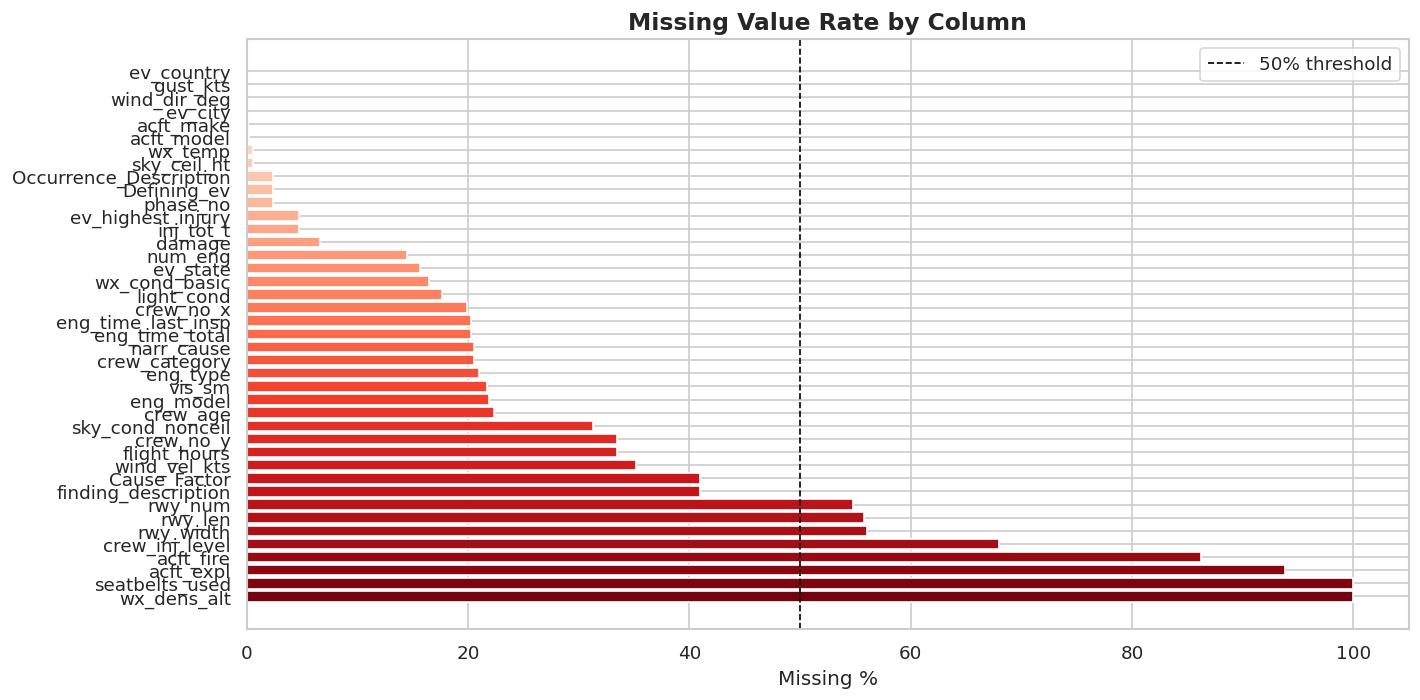

                column  missing_%
           wx_dens_alt 100.000000
        seatbelts_used 100.000000
             acft_expl  93.819847
             acft_fire  86.188905
        crew_inj_level  68.011983
             rwy_width  56.025313
               rwy_len  55.806517
               rwy_num  54.742830
   finding_description  40.999057
          Cause_Factor  40.999057
          wind_vel_kts  35.152148
          flight_hours  33.489296
             crew_no_y  33.489296
      sky_cond_nonceil  31.297967
              crew_age  22.391275
             eng_model  21.856066
                vis_sm  21.724788
              eng_type  20.960684
         crew_category  20.570217
            narr_cause  20.553386
        eng_time_total  20.274000
    eng_time_last_insp  20.274000
             crew_no_x  19.910462
            light_cond  17.618150
         wx_cond_basic  16.507338
              ev_state  15.655716
               num_eng  14.484314
                damage   6.617746
             i

In [9]:
# Missing Value Analysis & Imputation Strategy
missing = (df.isnull().mean() * 100).sort_values(ascending=False)
missing_df = missing[missing > 0].rename('missing_%').reset_index()
missing_df.columns = ['column', 'missing_%']

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(missing_df['column'], missing_df['missing_%'],
               color=sns.color_palette('Reds_r', len(missing_df)))
ax.set_xlabel('Missing %', fontsize=12)
ax.set_title('Missing Value Rate by Column', fontsize=14, fontweight='bold')
ax.axvline(50, color='black', linestyle='--', linewidth=1, label='50% threshold')
ax.legend()
plt.tight_layout()
plt.show()
print(missing_df.to_string(index=False))


In [10]:
# Drop Near-Empty Columns
MISS_THRESHOLD = 95  # % missing to warrant dropping
drop_cols = missing[missing > MISS_THRESHOLD].index.tolist()
print(f"Dropping {len(drop_cols)} columns with >{MISS_THRESHOLD}% missing: {drop_cols}")
df.drop(columns=drop_cols, inplace=True, errors='ignore')

# Numeric Imputation (median)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_cols:
    if df[col].isna().any():
        df[col].fillna(df[col].median(), inplace=True)

print("Remaining nulls after imputation:")
print(df.isnull().sum()[df.isnull().sum() > 0])


Dropping 2 columns with >95% missing: ['wx_dens_alt', 'seatbelts_used']
Remaining nulls after imputation:
ev_city                      16
ev_state                   4651
ev_country                    4
wx_cond_basic              4904
light_cond                 5234
sky_cond_nonceil           9298
sky_ceil_ht                 172
vis_sm                     6454
wind_dir_deg                 15
wind_vel_kts              10443
gust_kts                     15
wx_temp                     172
ev_highest_injury          1419
inj_tot_t                  1419
acft_make                    43
acft_model                   54
damage                     1966
acft_fire                 25605
acft_expl                 27872
num_eng                    4303
rwy_num                   16263
rwy_len                   16579
rwy_width                 16644
finding_description       12180
Cause_Factor              12180
narr_cause                 6106
crew_no_x                  5915
crew_category              611

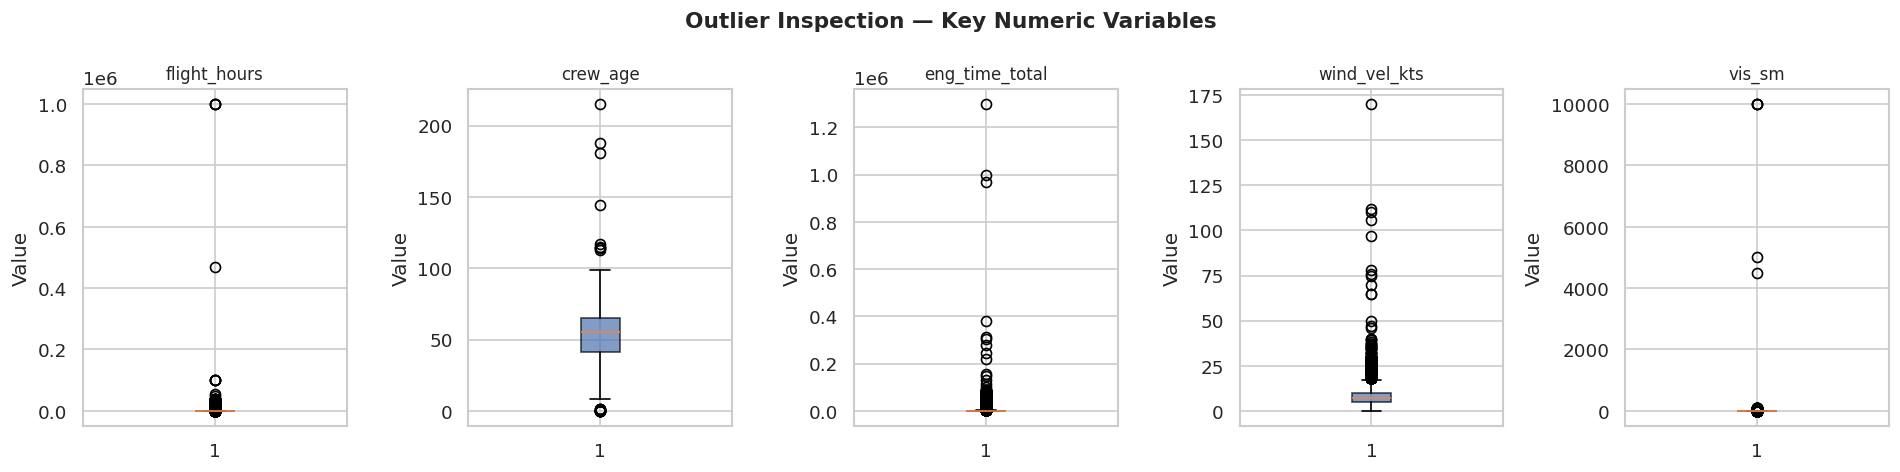

In [11]:
#  Outlier Inspection — Key Numeric Variables
outlier_cols = ['flight_hours', 'crew_age', 'eng_time_total', 'wind_vel_kts', 'vis_sm']
fig, axes = plt.subplots(1, len(outlier_cols), figsize=(16, 4))

for ax, col in zip(axes, outlier_cols):
    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='#4C72B0', alpha=0.7))
    ax.set_title(col, fontsize=10)
    ax.set_ylabel('Value')

plt.suptitle('Outlier Inspection — Key Numeric Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


Exploratory Data Analysis

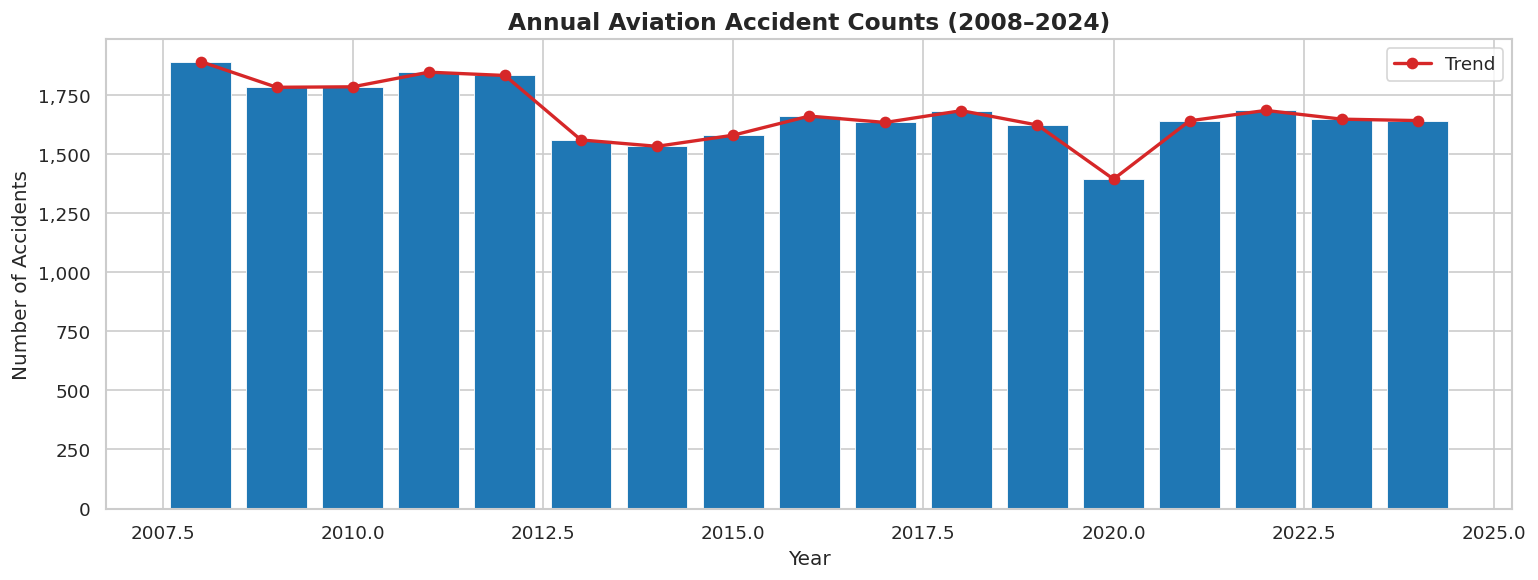

In [12]:
# Accident Counts by Year 
year_counts = df.groupby('year')['ev_id'].nunique().reset_index()
year_counts.columns = ['year', 'accidents']
# Exclude partial year 2025
year_counts = year_counts[year_counts['year'] < 2025]

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(year_counts['year'], year_counts['accidents'],
       color=PALETTE[0], edgecolor='white', linewidth=0.5)
ax.plot(year_counts['year'], year_counts['accidents'],
        marker='o', color='#d62728', linewidth=2, markersize=6, label='Trend')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Accidents', fontsize=12)
ax.set_title('Annual Aviation Accident Counts (2008–2024)', fontsize=14, fontweight='bold')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()


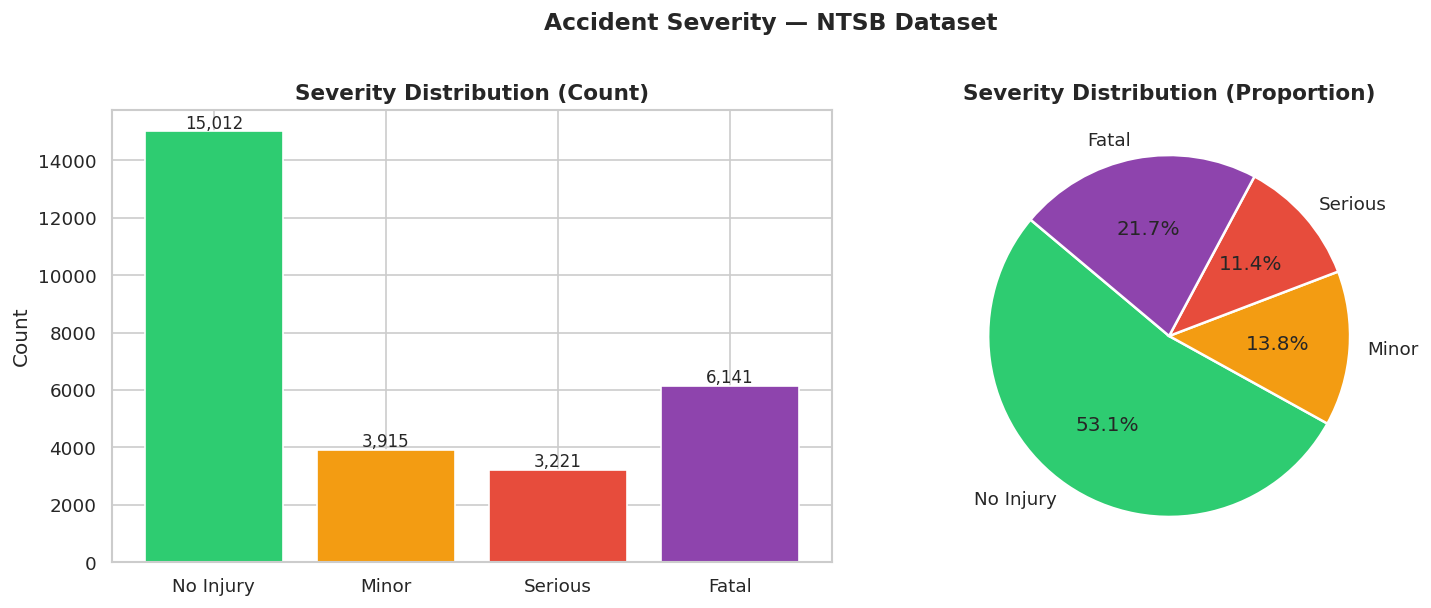

In [13]:
# Accident Severity Distribution 
sev_map  = {'NONE': 'No Injury', 'MINR': 'Minor', 'SERS': 'Serious', 'FATL': 'Fatal'}
sev_order = ['No Injury', 'Minor', 'Serious', 'Fatal']
sev_counts = (df['ev_highest_injury']
              .map(sev_map)
              .value_counts()
              .reindex(sev_order, fill_value=0))

colors_sev = ['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.bar(sev_counts.index, sev_counts.values, color=colors_sev, edgecolor='white')
ax1.set_ylabel('Count', fontsize=12)
ax1.set_title('Severity Distribution (Count)', fontsize=13, fontweight='bold')
for i, (cat, val) in enumerate(sev_counts.items()):
    ax1.text(i, val + 100, f'{val:,}', ha='center', fontsize=10)

ax2.pie(sev_counts.values, labels=sev_counts.index, colors=colors_sev,
        autopct='%1.1f%%', startangle=140,
        wedgeprops=dict(edgecolor='white', linewidth=1.5))
ax2.set_title('Severity Distribution (Proportion)', fontsize=13, fontweight='bold')

plt.suptitle('Accident Severity — NTSB Dataset', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


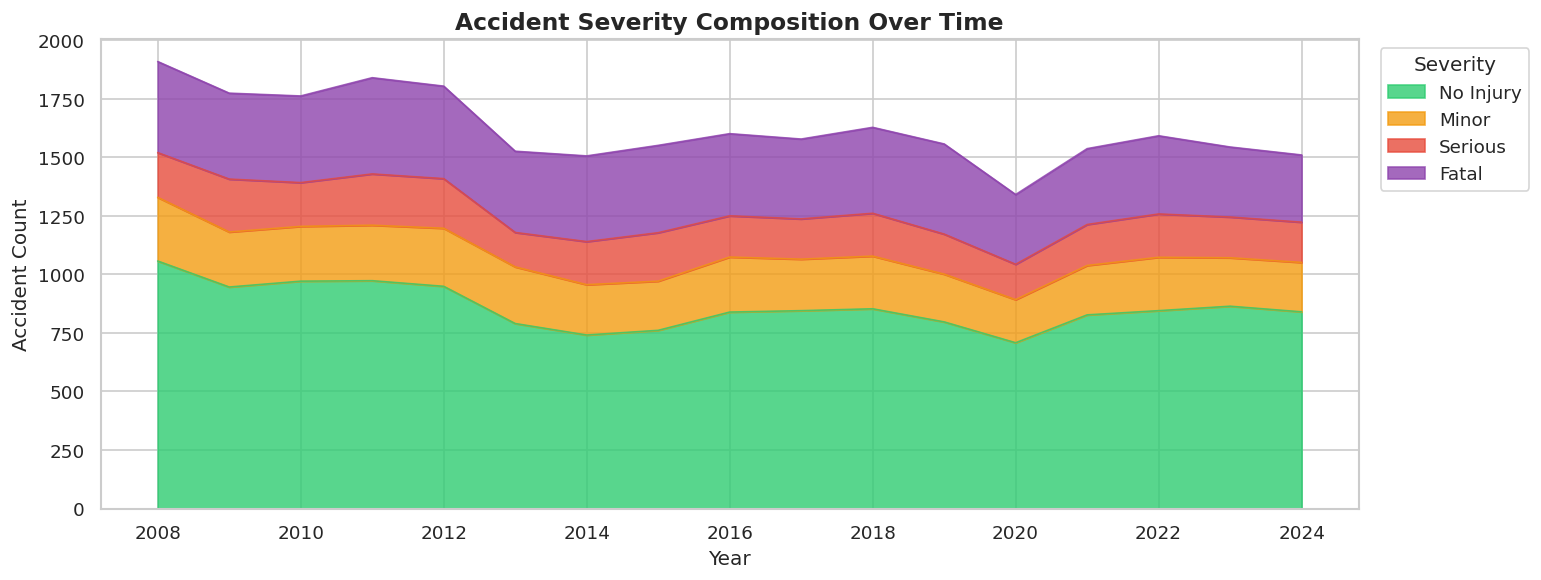

In [14]:
# Severity Trend Over Time 
sev_trend = (df[df['year'] < 2025]
             .groupby(['year', 'ev_highest_injury'])['ev_id']
             .count()
             .unstack(fill_value=0)
             .rename(columns=sev_map))

fig, ax = plt.subplots(figsize=(13, 5))
sev_trend[sev_order].plot(
    ax=ax, kind='area', stacked=True,
    color=colors_sev, alpha=0.8, linewidth=1)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Accident Count', fontsize=12)
ax.set_title('Accident Severity Composition Over Time', fontsize=14, fontweight='bold')
ax.legend(title='Severity', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()


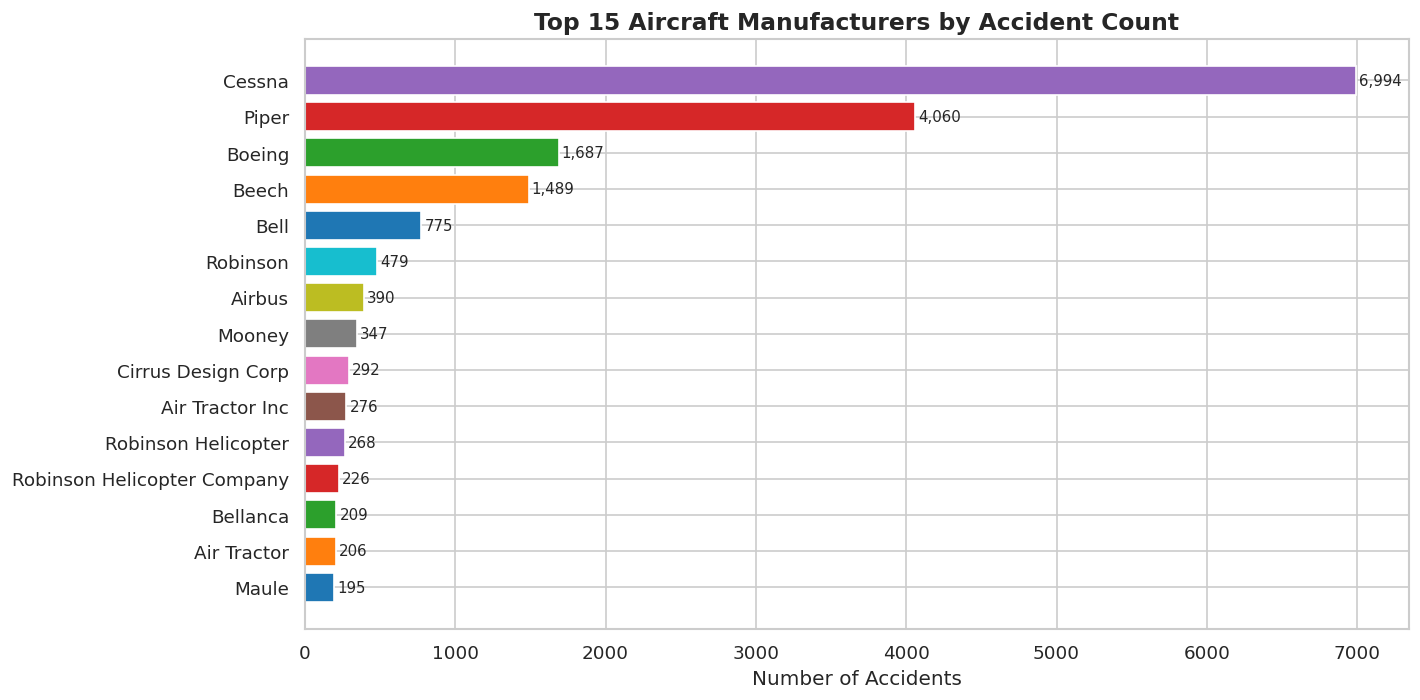

In [15]:
# Top Aircraft Manufacturers by Accident Count
# Normalise manufacturer name casing
df['acft_make_clean'] = df['acft_make'].str.title()
make_counts = (df['acft_make_clean'].value_counts().head(15))

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(make_counts.index[::-1], make_counts.values[::-1], color=PALETTE)
ax.set_xlabel('Number of Accidents', fontsize=12)
ax.set_title('Top 15 Aircraft Manufacturers by Accident Count', fontsize=14, fontweight='bold')
for i, (_, val) in enumerate(make_counts[::-1].items()):
    ax.text(val + 20, i, f'{val:,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()


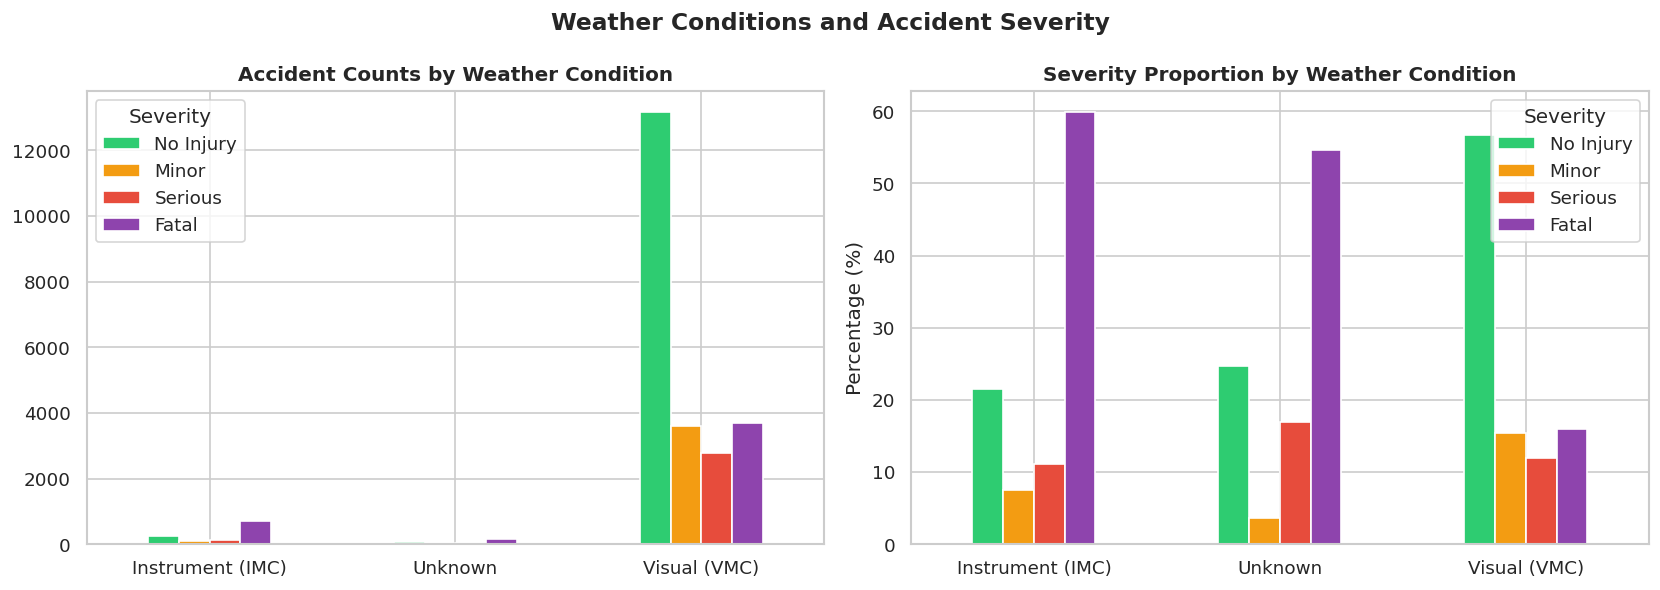

In [16]:
# Weather Condition Analysis 
wx_map = {'VMC': 'Visual (VMC)', 'IMC': 'Instrument (IMC)', 'UNK': 'Unknown'}
wx_sev = (df.dropna(subset=['wx_cond_basic', 'ev_highest_injury'])
           .groupby(['wx_cond_basic', 'ev_highest_injury'])
           .size()
           .unstack(fill_value=0)
           .rename(index=wx_map, columns=sev_map))

# Proportion of fatal accidents by weather condition
wx_fatal_pct = wx_sev.div(wx_sev.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
wx_sev[sev_order].plot(kind='bar', ax=axes[0], color=colors_sev, edgecolor='white')
axes[0].set_title('Accident Counts by Weather Condition', fontsize=12, fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Severity')

wx_fatal_pct[sev_order].plot(kind='bar', ax=axes[1], color=colors_sev, edgecolor='white')
axes[1].set_title('Severity Proportion by Weather Condition', fontsize=12, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Severity')

plt.suptitle('Weather Conditions and Accident Severity', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


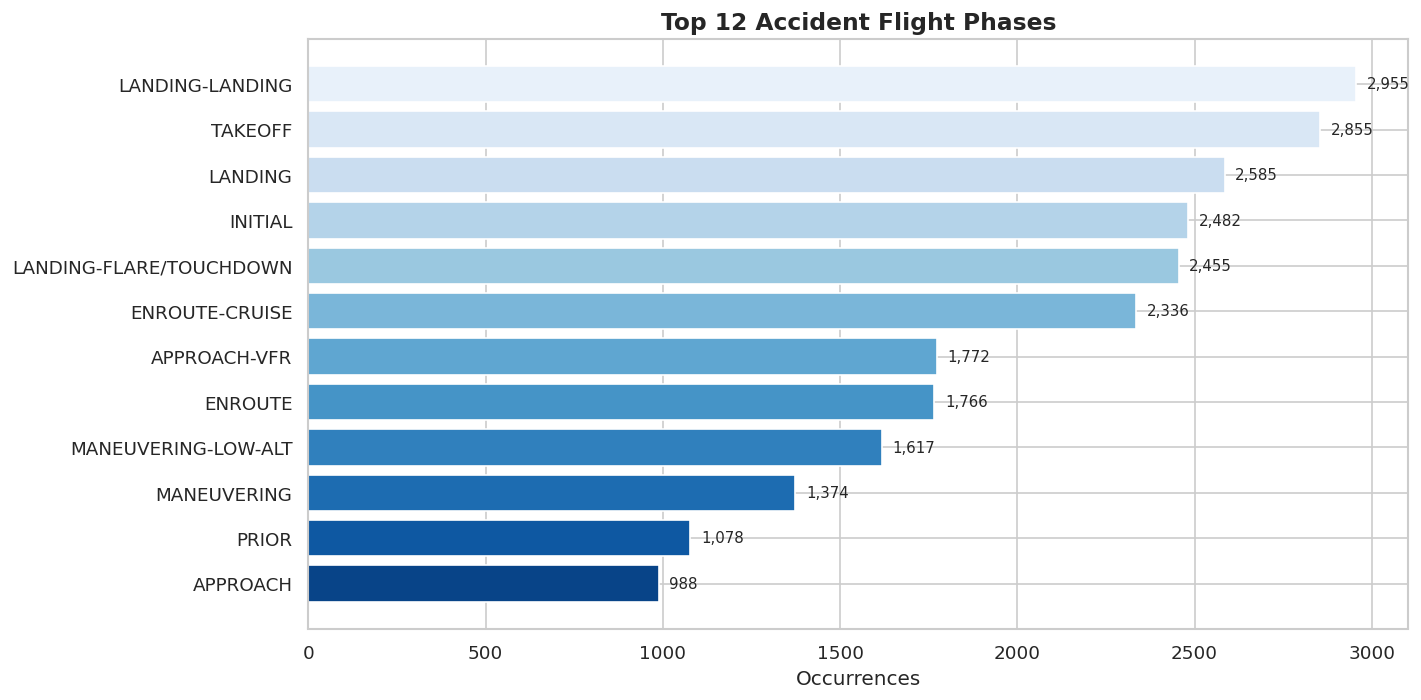

In [17]:
# Flight Phase Analysis 
phase_series = df['Occurrence_Description'].dropna().str.split(' ', n=1).str[0]
phase_counts = phase_series.value_counts().head(12)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(phase_counts.index[::-1], phase_counts.values[::-1],
        color=sns.color_palette('Blues_r', len(phase_counts)))
ax.set_xlabel('Occurrences', fontsize=12)
ax.set_title('Top 12 Accident Flight Phases', fontsize=14, fontweight='bold')
for i, v in enumerate(phase_counts.values[::-1]):
    ax.text(v + 30, i, f'{v:,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()


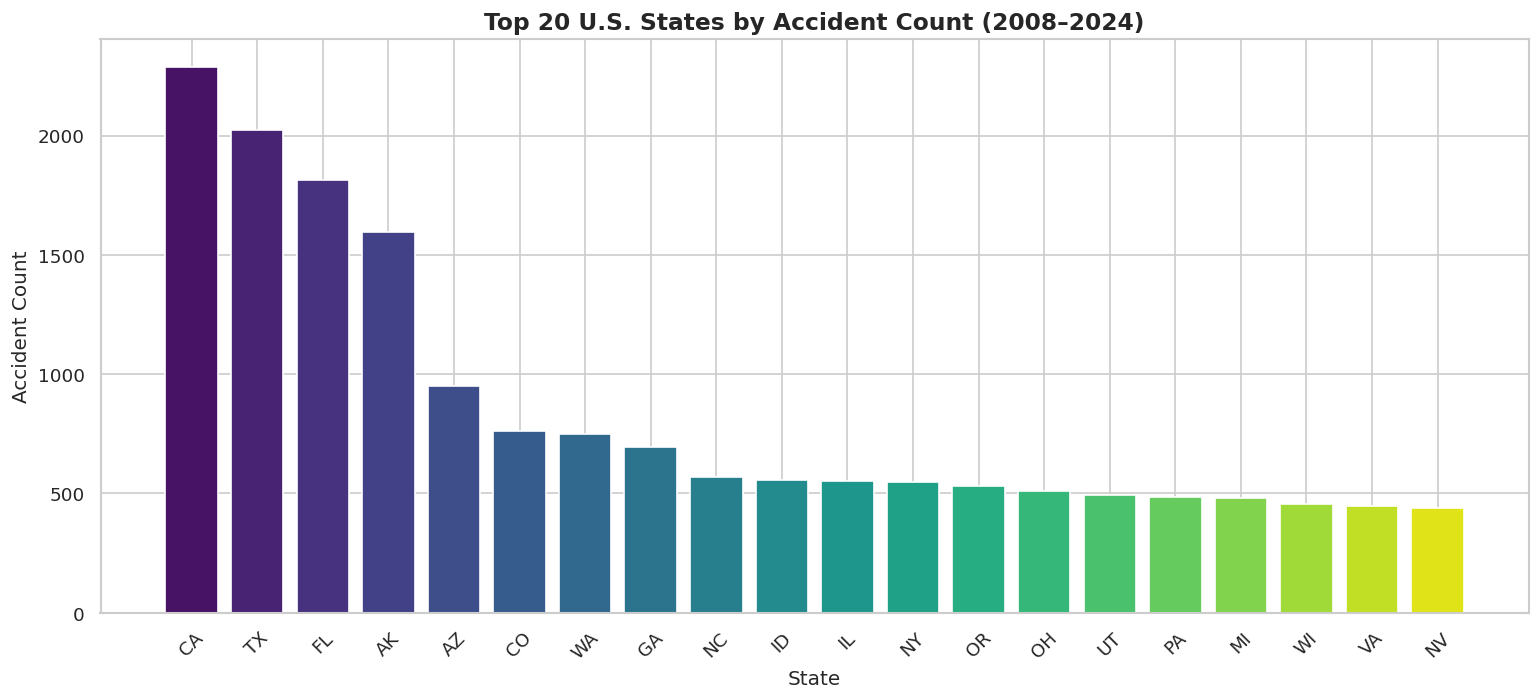

In [18]:
# Geographic Analysis — Accidents by U.S. State 
state_counts = df[df['ev_country'] == 'USA']['ev_state'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(state_counts.index, state_counts.values,
       color=sns.color_palette('viridis', len(state_counts)))
ax.set_xlabel('State', fontsize=12)
ax.set_ylabel('Accident Count', fontsize=12)
ax.set_title('Top 20 U.S. States by Accident Count (2008–2024)', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


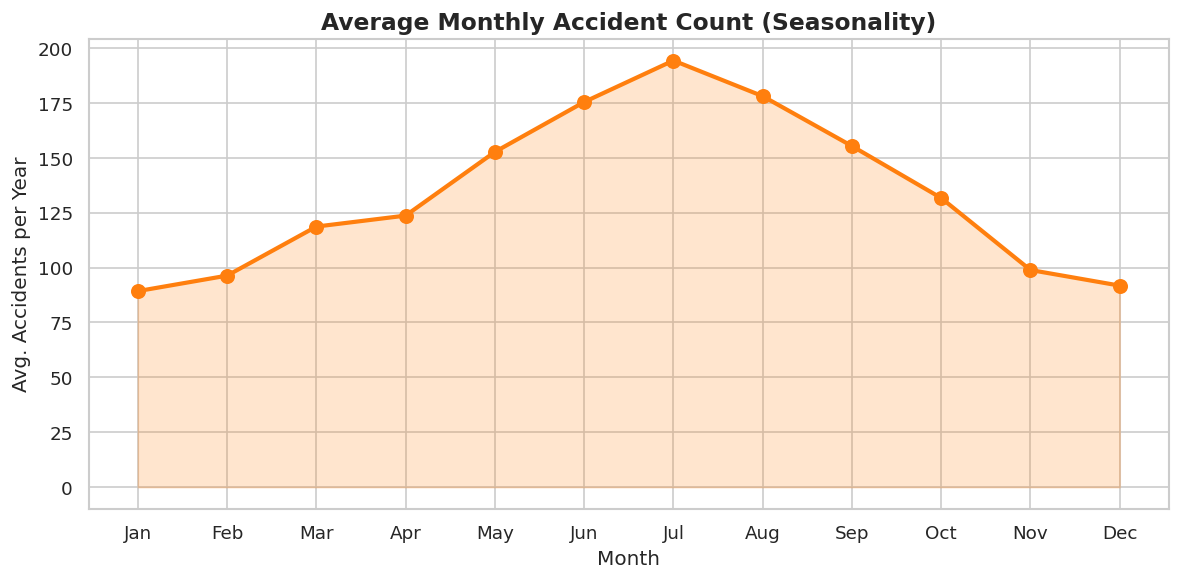

In [20]:
# Monthly Seasonality
monthly_avg = (df[df['year'] < 2025]
               .groupby('month')['ev_id']
               .count() / df['year'].nunique())

month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(month_labels, monthly_avg.values, marker='o', linewidth=2.5,
        color=PALETTE[1], markersize=8)
ax.fill_between(month_labels, monthly_avg.values, alpha=0.2, color=PALETTE[1])
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Avg. Accidents per Year', fontsize=12)
ax.set_title('Average Monthly Accident Count (Seasonality)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


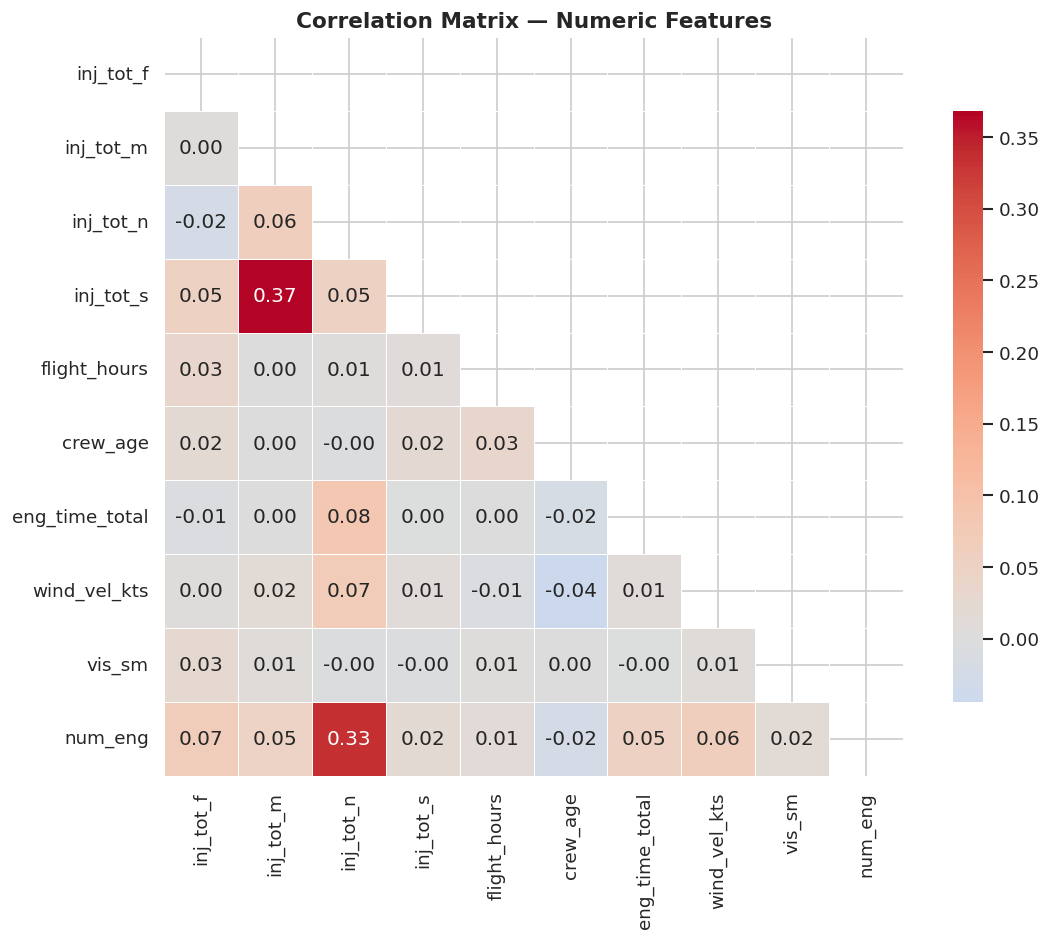

In [21]:
# Correlation Matrix 
corr_cols = ['inj_tot_f', 'inj_tot_m', 'inj_tot_n', 'inj_tot_s',
             'flight_hours', 'crew_age', 'eng_time_total',
             'wind_vel_kts', 'vis_sm', 'num_eng']

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True,
            linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix — Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


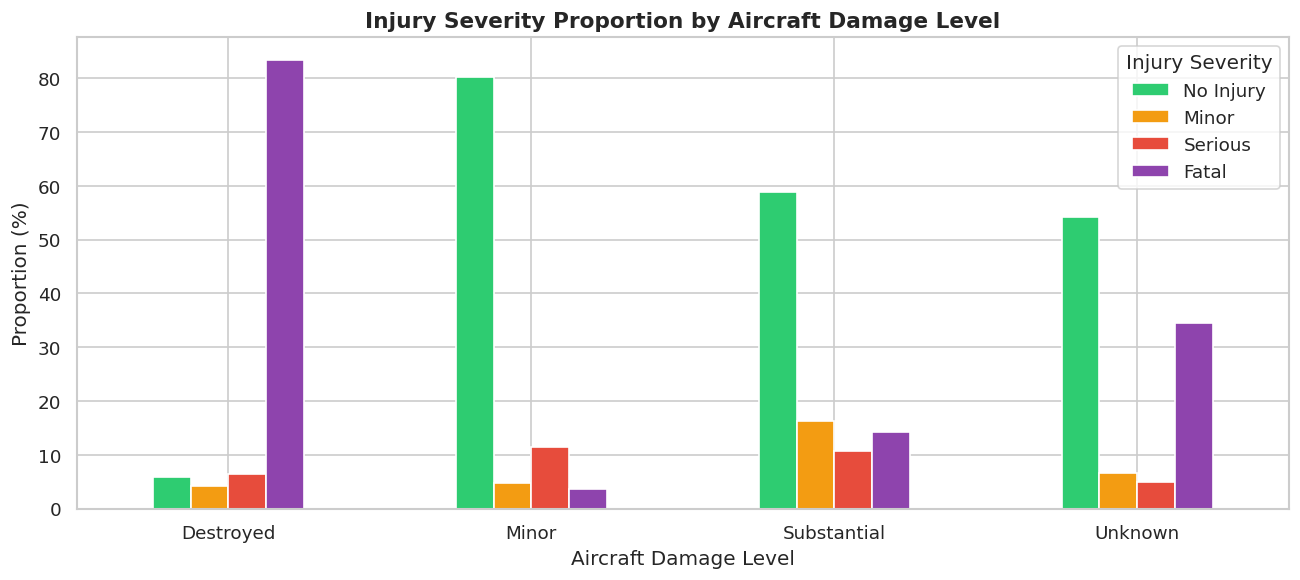

In [22]:
# Aircraft Damage vs Injury Severity 
dmg_map  = {'DEST': 'Destroyed', 'SUBS': 'Substantial', 'MINR': 'Minor', 'UNK': 'Unknown'}
cross = pd.crosstab(
    df['damage'].map(dmg_map),
    df['ev_highest_injury'].map(sev_map),
    normalize='index') * 100

cross_plot = cross.reindex(columns=sev_order, fill_value=0)

fig, ax = plt.subplots(figsize=(11, 5))
cross_plot.plot(kind='bar', ax=ax, color=colors_sev, edgecolor='white')
ax.set_xlabel('Aircraft Damage Level', fontsize=12)
ax.set_ylabel('Proportion (%)', fontsize=12)
ax.set_title('Injury Severity Proportion by Aircraft Damage Level', fontsize=13, fontweight='bold')
ax.legend(title='Injury Severity')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


Feature Engineering

In [23]:
# Create Modelling DataFrame
df_model = df.copy()

# Drop rows with missing target
df_model.dropna(subset=['ev_highest_injury'], inplace=True)
df_model = df_model[df_model['ev_highest_injury'].isin(['NONE', 'MINR', 'SERS', 'FATL'])]

print(f"Modelling rows: {len(df_model):,}")
print(df_model['ev_highest_injury'].value_counts())


Modelling rows: 28,289
ev_highest_injury
NONE    15012
FATL     6141
MINR     3915
SERS     3221
Name: count, dtype: int64


In [24]:
# Encode Categorical Features 
# Weather condition
df_model['wx_imc'] = (df_model['wx_cond_basic'] == 'IMC').astype(int)
# Homebuilt aircraft flag
df_model['is_homebuilt'] = (df_model['homebuilt'] == 'Y').astype(int)
# Aircraft fire flag
df_model['had_fire'] = (df_model['acft_fire'] == 'YES').astype(int)
# Aircraft explosion flag
df_model['had_expl'] = (df_model['acft_expl'] == 'YES').astype(int)

# Damage level — ordinal encoding (MINR=1, SUBS=2, DEST=3)
dmg_ord = {'MINR': 1, 'SUBS': 2, 'DEST': 3, 'UNK': 0}
df_model['damage_ord'] = df_model['damage'].map(dmg_ord).fillna(0)

# Day of week — is it a weekend?
df_model['is_weekend'] = (df_model['day_of_week'] >= 5).astype(int)

print("Engineered binary/ordinal features created.")


Engineered binary/ordinal features created.


In [25]:
# Encode Target Variable 
# Ordinal encoding: NONE=0, MINR=1, SERS=2, FATL=3
sev_ordinal = {'NONE': 0, 'MINR': 1, 'SERS': 2, 'FATL': 3}
df_model['severity_code'] = df_model['ev_highest_injury'].map(sev_ordinal)

# Binary target: Fatal vs. Non-fatal (for binary classification tasks)
df_model['is_fatal'] = (df_model['ev_highest_injury'] == 'FATL').astype(int)

print("Severity code distribution:")
print(df_model['severity_code'].value_counts().sort_index())


Severity code distribution:
severity_code
0    15012
1     3915
2     3221
3     6141
Name: count, dtype: int64


The machine learning models are going to look at this data to try and make predictions, but right now, some of the numbers are too wildly uneven, and some words are still too complex. The code below does three distinct upgrades to make the numbers smooth and easy for the computer.

In [27]:
# Log-Transform Skewed Numerics 
# Avoids extreme-value distortion in linear models
for col in ['flight_hours', 'eng_time_total']:
    df_model[f'log_{col}'] = np.log1p(df_model[col])

# Injury Ratio Feature 
# Ratio of fatal injuries to total occupants
df_model['fatal_ratio'] = df_model['inj_tot_f'] / (df_model['inj_tot_t'].replace(0, 1))

# Phase Category 
# Simplify occurrence description to high-level flight phase
phase_raw = df_model['Occurrence_Description'].fillna('').str.split(' ', n=1).str[0]
top_phases = phase_raw.value_counts().head(10).index
df_model['phase_cat'] = phase_raw.where(phase_raw.isin(top_phases), other='OTHER')

le_phase = LabelEncoder()
df_model['phase_enc'] = le_phase.fit_transform(df_model['phase_cat'].fillna('UNKNOWN'))

print("Phase categories:", df_model['phase_cat'].unique())


Phase categories: ['LANDING' 'INITIAL' 'OTHER' 'LANDING-FLARE/TOUCHDOWN' 'APPROACH-VFR'
 'LANDING-LANDING' 'MANEUVERING' 'ENROUTE-CRUISE' 'TAKEOFF'
 'MANEUVERING-LOW-ALT' 'ENROUTE']


In [28]:
# Final Feature Selection 
FEATURE_COLS = [
    # Numeric weather
    'wind_vel_kts', 'vis_sm', 'wx_temp',
    # Binary weather
    'wx_imc',
    # Temporal
    'month', 'day_of_week', 'quarter', 'is_weekend', 'year',
    # Aircraft
    'damage_ord', 'is_homebuilt', 'had_fire', 'had_expl', 'num_eng',
    # Crew
    'crew_age', 'log_flight_hours',
    # Engine
    'log_eng_time_total',
    # Phase
    'phase_enc',
    # Runway
    'rwy_len', 'rwy_width',
]

TARGET_COL = 'severity_code'  # 4-class ordinal target

X = df_model[FEATURE_COLS].copy()
y = df_model[TARGET_COL].copy()

# Final check for remaining nulls (fill with median)
X.fillna(X.median(), inplace=True)

print(f"Feature matrix shape : {X.shape}")
print(f"Target distribution  :\n{y.value_counts().sort_index()}")


Feature matrix shape : (28289, 20)
Target distribution  :
severity_code
0    15012
1     3915
2     3221
3     6141
Name: count, dtype: int64


Accident Severity Prediction (Classification)

In [29]:
# Train / Test Split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")
print("\nClass distribution — train:")
print(y_train.value_counts().sort_index())


Train: 22,631 | Test: 5,658

Class distribution — train:
severity_code
0    12009
1     3132
2     2577
3     4913
Name: count, dtype: int64


In [30]:
# Scale Features 
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Sample weights for imbalanced classes
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)


In [31]:
# Define Models 
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42, C=1.0),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=12, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=15, class_weight='balanced',
        random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42),
}

if XGB_AVAILABLE:
    models['XGBoost'] = xgb.XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        use_label_encoder=False, eval_metric='mlogloss',
        random_state=42, n_jobs=-1)

print(f"Models to train: {list(models.keys())}")


Models to train: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'XGBoost']


In [32]:
# Cross-Validation & Test Evaluation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    print(f"Training {name}...")
    
    # Use scaled features for LR, raw for tree-based
    X_tr = X_train_sc if name == 'Logistic Regression' else X_train.values
    X_te = X_test_sc  if name == 'Logistic Regression' else X_test.values

    # Cross-validation accuracy
    cv_scores = cross_val_score(model, X_tr, y_train, cv=cv,
                                scoring='accuracy', n_jobs=-1)
    
    # Fit on full training set
    if name in ('Gradient Boosting', 'XGBoost'):
        model.fit(X_tr, y_train, sample_weight=sample_weights)
    else:
        model.fit(X_tr, y_train)
    
    y_pred = model.predict(X_te)
    
    results[name] = {
        'model'   : model,
        'y_pred'  : y_pred,
        'cv_mean' : cv_scores.mean(),
        'cv_std'  : cv_scores.std(),
    }
    print(f"  CV Accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

print("\nAll models trained.")


Training Logistic Regression...
  CV Accuracy: 0.437 ± 0.008
Training Decision Tree...
  CV Accuracy: 0.473 ± 0.007
Training Random Forest...
  CV Accuracy: 0.558 ± 0.007
Training Gradient Boosting...
  CV Accuracy: 0.649 ± 0.002
Training XGBoost...
  CV Accuracy: 0.650 ± 0.003

All models trained.


In [ ]:
# Classification Reports 
sev_labels = ['None (0)', 'Minor (1)', 'Serious (2)', 'Fatal (3)']

for name, res in results.items():
    print(f"\n{'='*60}")
    print(f" {name}")
    print('='*60)
    print(classification_report(y_test, res['y_pred'],
                                target_names=sev_labels, zero_division=0))



 Logistic Regression
              precision    recall  f1-score   support

    None (0)       0.72      0.39      0.51      3003
   Minor (1)       0.20      0.38      0.26       783
 Serious (2)       0.21      0.29      0.24       644
   Fatal (3)       0.52      0.69      0.59      1228

    accuracy                           0.44      5658
   macro avg       0.41      0.44      0.40      5658
weighted avg       0.55      0.44      0.46      5658


 Decision Tree
              precision    recall  f1-score   support

    None (0)       0.79      0.45      0.57      3003
   Minor (1)       0.18      0.40      0.25       783
 Serious (2)       0.22      0.32      0.26       644
   Fatal (3)       0.61      0.65      0.63      1228

    accuracy                           0.47      5658
   macro avg       0.45      0.45      0.43      5658
weighted avg       0.60      0.47      0.51      5658


 Random Forest
              precision    recall  f1-score   support

    None (0)       0.

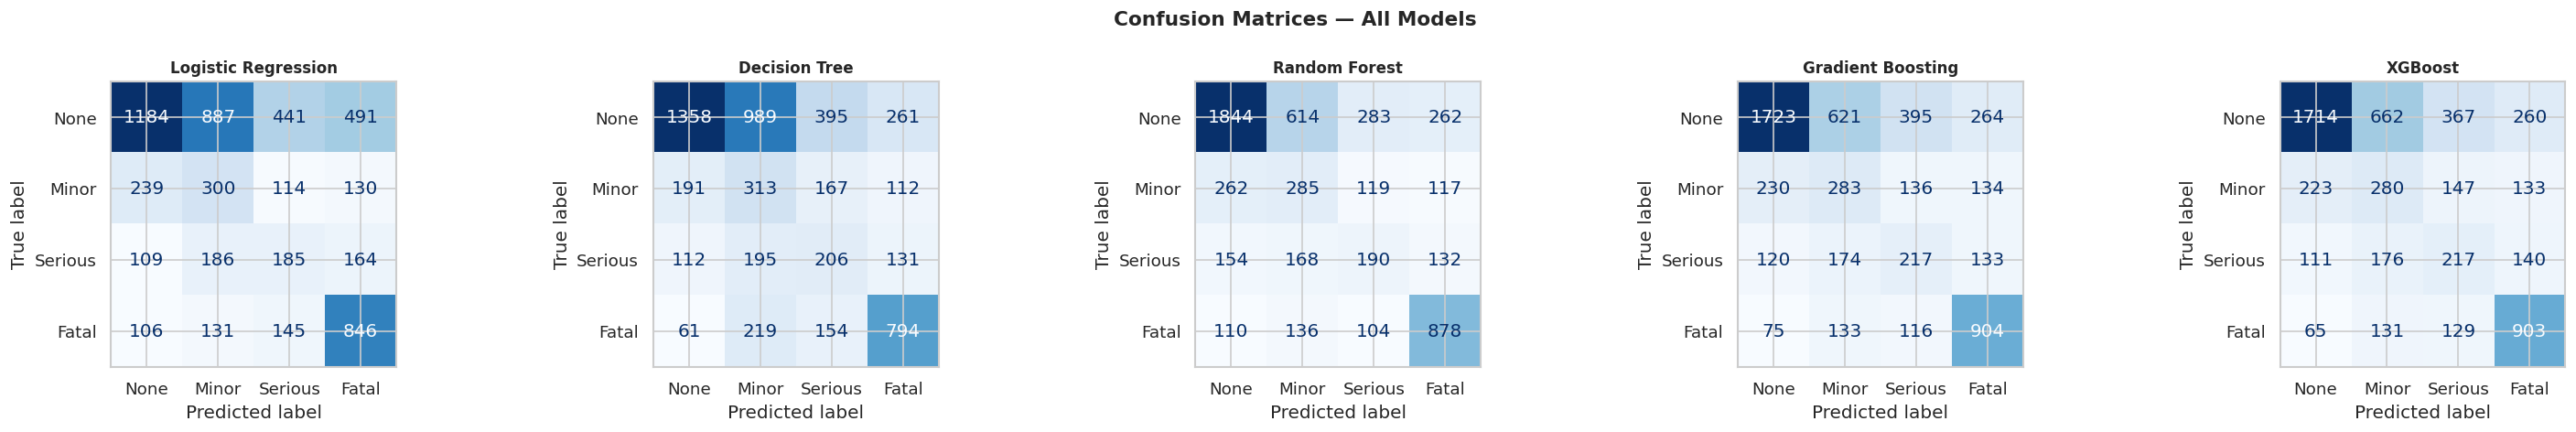

In [ ]:
# Confusion Matrices 
n_models = len(results)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4))
if n_models == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['None','Minor','Serious','Fatal'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=10, fontweight='bold')

plt.suptitle('Confusion Matrices — All Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# Model Comparison Table 
from sklearn.metrics import accuracy_score, f1_score

comparison = []
for name, res in results.items():
    acc = accuracy_score(y_test, res['y_pred'])
    f1w = f1_score(y_test, res['y_pred'], average='weighted', zero_division=0)
    f1m = f1_score(y_test, res['y_pred'], average='macro',    zero_division=0)
    comparison.append({
        'Model'         : name,
        'CV Accuracy'   : f"{res['cv_mean']:.4f} ± {res['cv_std']:.4f}",
        'Test Accuracy' : round(acc, 4),
        'F1-Weighted'   : round(f1w, 4),
        'F1-Macro'      : round(f1m, 4),
    })

comparison_df = pd.DataFrame(comparison).sort_values('Test Accuracy', ascending=False)
print(comparison_df.to_string(index=False))


              Model     CV Accuracy  Test Accuracy  F1-Weighted  F1-Macro
      Random Forest 0.5582 ± 0.0068         0.5650       0.5819    0.4820
  Gradient Boosting 0.6492 ± 0.0019         0.5527       0.5745    0.4799
            XGBoost 0.6498 ± 0.0032         0.5504       0.5738    0.4780
      Decision Tree 0.4728 ± 0.0066         0.4721       0.5061    0.4293
Logistic Regression 0.4371 ± 0.0084         0.4445       0.4631    0.4016


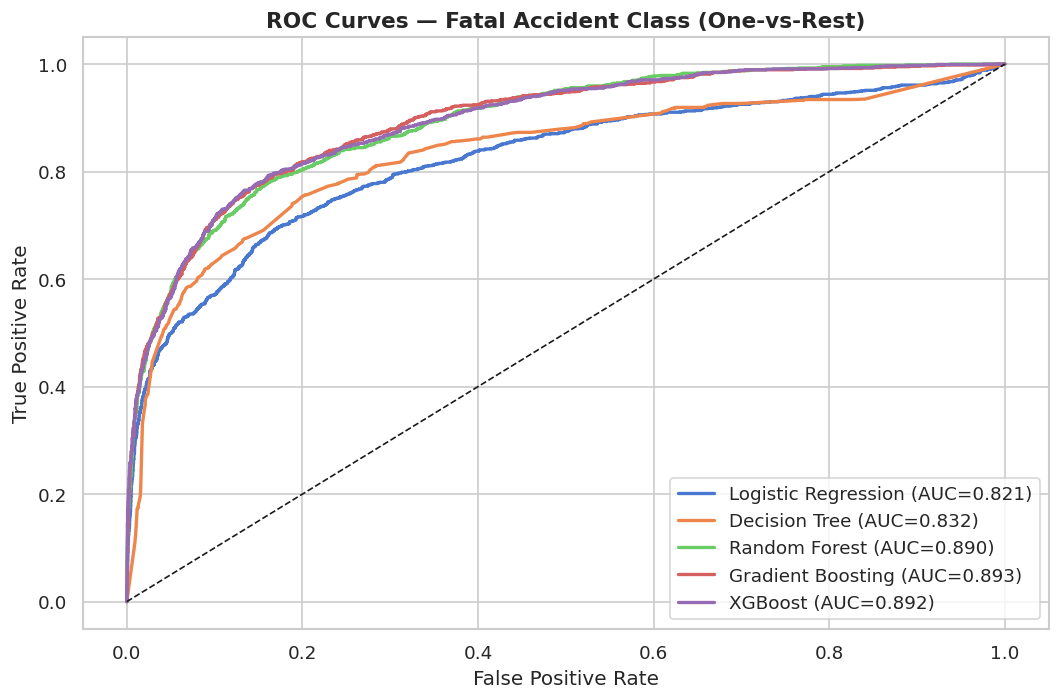

In [33]:
# ROC Curves (One-vs-Rest, Fatal class) 
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])

fig, ax = plt.subplots(figsize=(9, 6))
for name, res in results.items():
    model = res['model']
    X_te  = X_test_sc if name == 'Logistic Regression' else X_test.values
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_te)
        fpr, tpr, _ = roc_curve(y_test_bin[:, 3], y_prob[:, 3])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Fatal Accident Class (One-vs-Rest)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


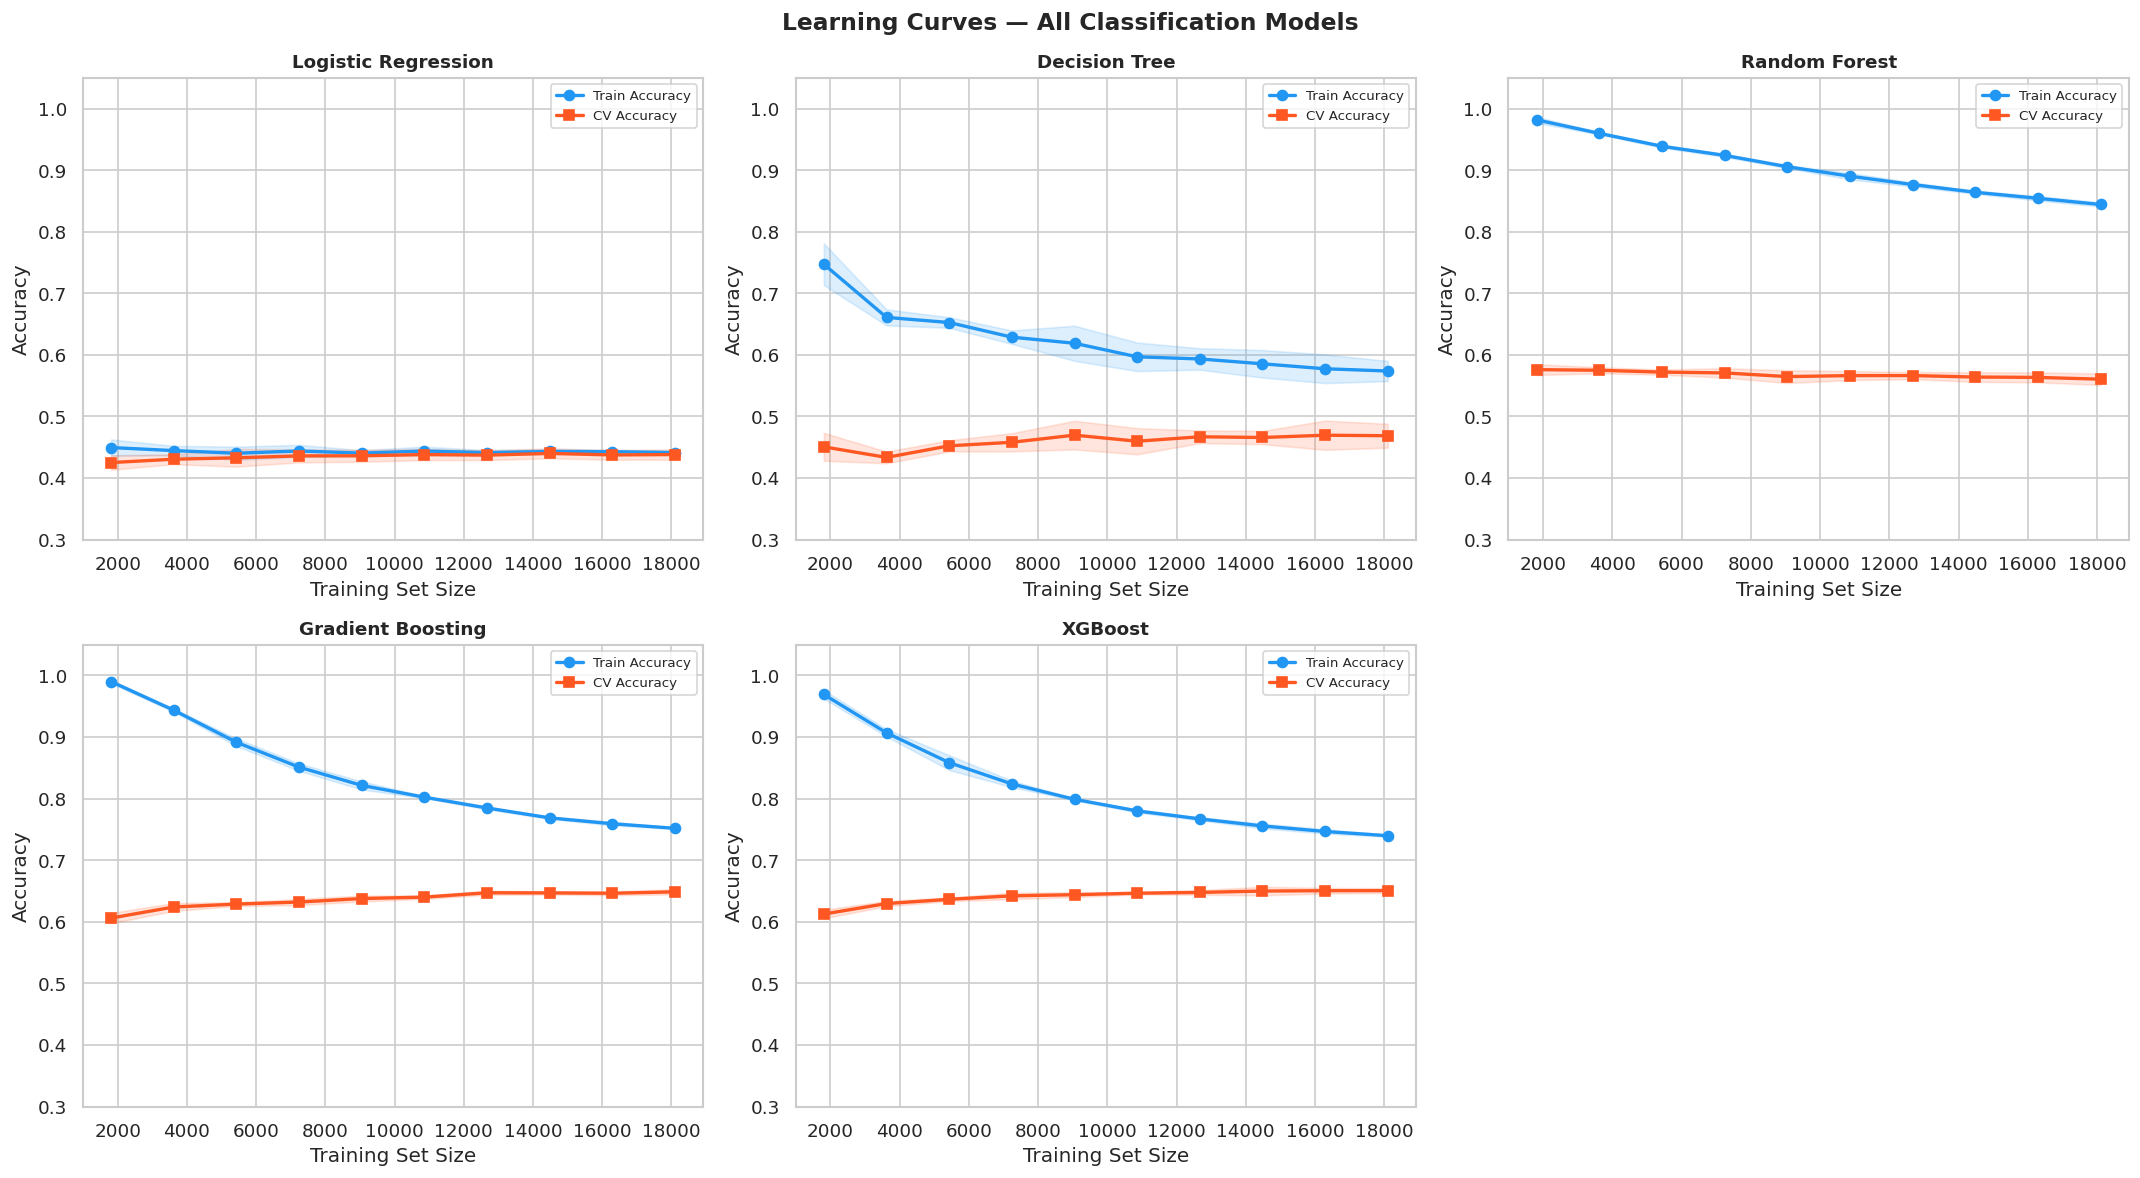

In [34]:
# Learning Curves 
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

lc_models = {
    'Logistic Regression': (results['Logistic Regression']['model'], X_train_sc),
    'Decision Tree'      : (results['Decision Tree']['model'],       X_train.values),
    'Random Forest'      : (results['Random Forest']['model'],       X_train.values),
    'Gradient Boosting'  : (results['Gradient Boosting']['model'],   X_train.values),
}
if XGB_AVAILABLE:
    lc_models['XGBoost'] = (results['XGBoost']['model'], X_train.values)

for ax, (name, (model, X_tr)) in zip(axes, lc_models.items()):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_tr, y_train,
        cv=5, scoring='accuracy',
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1, shuffle=True, random_state=42
    )
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    ax.plot(train_sizes, train_mean, 'o-', color='#2196F3', label='Train Accuracy', linewidth=2)
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#2196F3')
    ax.plot(train_sizes, val_mean, 's-', color='#FF5722', label='CV Accuracy', linewidth=2)
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#FF5722')
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Training Set Size')
    ax.set_ylabel('Accuracy')
    ax.legend(fontsize=8)
    ax.set_ylim([0.3, 1.05])

# Hide unused subplot if models < 6
for ax in axes[len(lc_models):]:
    ax.set_visible(False)

plt.suptitle('Learning Curves — All Classification Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

comparison_df rebuilt.


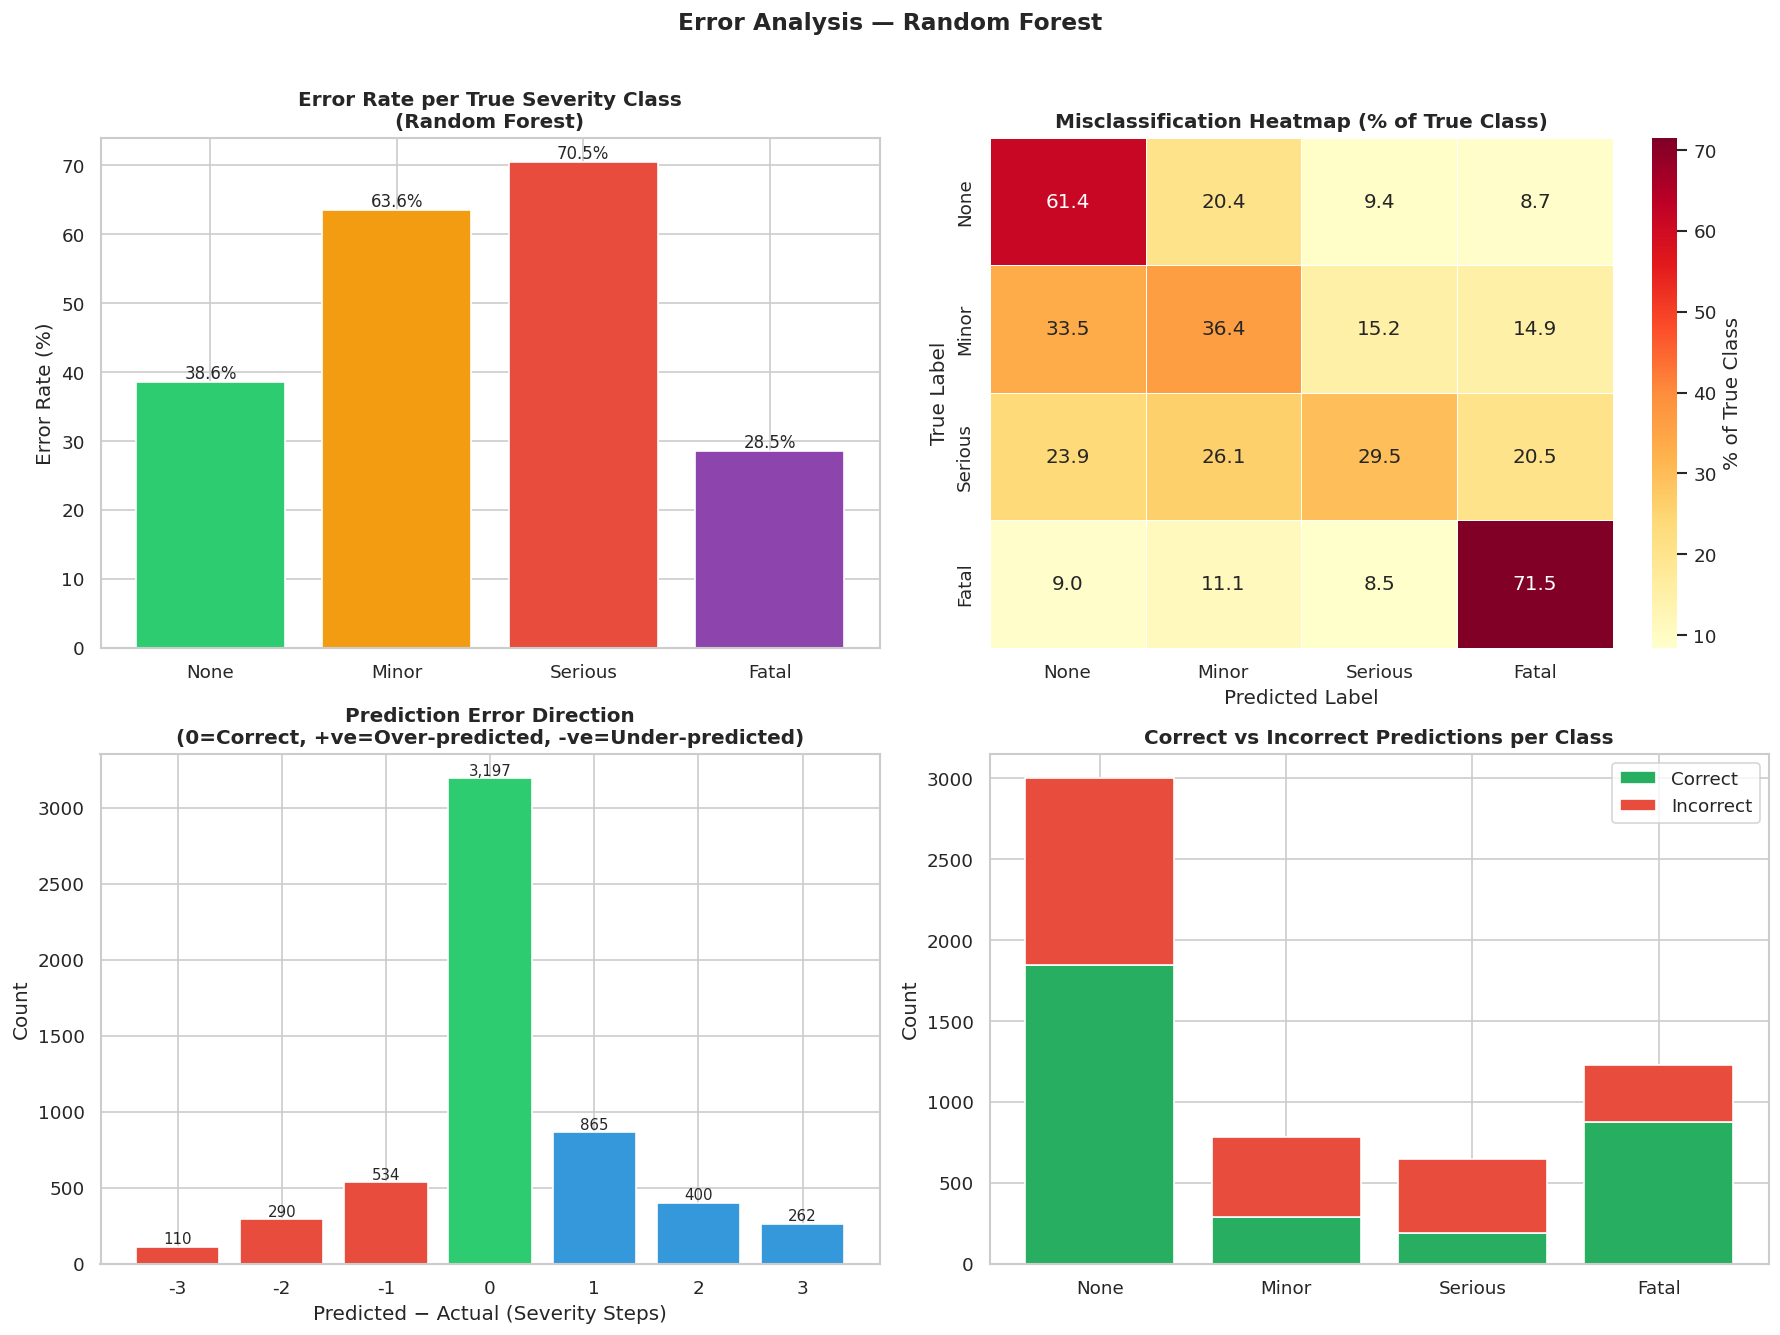


Error Analysis Summary:
              Total  Correct Error_Rate  Avg_Error
actual_label                                      
None           3003     1844      38.6%      0.655
Minor           783      285      63.6%      0.116
Serious         644      190      70.5%     -0.534
Fatal          1228      878      28.5%     -0.575


In [ ]:
# Error Analysis — Best Model 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score

# rebuild comparison_df if kernel lost it 
if 'comparison_df' not in dir():
    comparison = []
    for name, res in results.items():
        acc = accuracy_score(y_test, res['y_pred'])
        f1w = f1_score(y_test, res['y_pred'], average='weighted', zero_division=0)
        f1m = f1_score(y_test, res['y_pred'], average='macro',    zero_division=0)
        comparison.append({
            'Model'         : name,
            'CV Accuracy'   : f"{res['cv_mean']:.4f} ± {res['cv_std']:.4f}",
            'Test Accuracy' : round(acc, 4),
            'F1-Weighted'   : round(f1w, 4),
            'F1-Macro'      : round(f1m, 4),
        })
    comparison_df = pd.DataFrame(comparison).sort_values('Test Accuracy', ascending=False)
    print("comparison_df rebuilt.")

best_name   = comparison_df.iloc[0]['Model']
y_pred_best = results[best_name]['y_pred']

sev_label_map = {0: 'None', 1: 'Minor', 2: 'Serious', 3: 'Fatal'}

error_df = pd.DataFrame({
    'actual'   : y_test.values,
    'predicted': y_pred_best
})
error_df['correct']         = error_df['actual'] == error_df['predicted']
error_df['actual_label']    = error_df['actual'].map(sev_label_map)
error_df['predicted_label'] = error_df['predicted'].map(sev_label_map)
error_df['error_direction'] = error_df['predicted'] - error_df['actual']
# +ve = over-predicted severity, -ve = under-predicted severity

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Error rate per true class 
order = ['None', 'Minor', 'Serious', 'Fatal']
error_rate = error_df.groupby('actual_label')['correct'].apply(
    lambda x: (1 - x.mean()) * 100).reindex(order)
axes[0,0].bar(error_rate.index, error_rate.values,
              color=['#2ecc71','#f39c12','#e74c3c','#8e44ad'], edgecolor='white')
axes[0,0].set_title(f'Error Rate per True Severity Class\n({best_name})',
                    fontsize=12, fontweight='bold')
axes[0,0].set_ylabel('Error Rate (%)')
for i, v in enumerate(error_rate.values):
    axes[0,0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10)

# Misclassification heatmap
misclass = pd.crosstab(error_df['actual_label'], error_df['predicted_label'],
                       normalize='index') * 100
misclass = misclass.reindex(index=order, columns=order, fill_value=0)
sns.heatmap(misclass, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[0,1], cbar_kws={'label': '% of True Class'})
axes[0,1].set_title('Misclassification Heatmap (% of True Class)',
                    fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('Predicted Label')
axes[0,1].set_ylabel('True Label')

# Error direction distribution 
err_counts = error_df['error_direction'].value_counts().sort_index()
colors_dir = ['#e74c3c' if x < 0 else ('#2ecc71' if x == 0 else '#3498db')
              for x in err_counts.index]
axes[1,0].bar(err_counts.index.astype(str), err_counts.values,
              color=colors_dir, edgecolor='white')
axes[1,0].set_title('Prediction Error Direction\n(0=Correct, +ve=Over-predicted, -ve=Under-predicted)',
                    fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Predicted − Actual (Severity Steps)')
axes[1,0].set_ylabel('Count')
for i, v in enumerate(err_counts.values):
    axes[1,0].text(i, v + 20, f'{v:,}', ha='center', fontsize=9)

# Correct vs Incorrect per class 
correct_counts   = error_df[error_df['correct']].groupby('actual_label').size().reindex(order, fill_value=0)
incorrect_counts = error_df[~error_df['correct']].groupby('actual_label').size().reindex(order, fill_value=0)
x = np.arange(len(order))
axes[1,1].bar(x, correct_counts.values,   label='Correct',   color='#27ae60', edgecolor='white')
axes[1,1].bar(x, incorrect_counts.values, label='Incorrect', color='#e74c3c',
              bottom=correct_counts.values, edgecolor='white')
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(order)
axes[1,1].set_title('Correct vs Incorrect Predictions per Class',
                    fontsize=12, fontweight='bold')
axes[1,1].set_ylabel('Count')
axes[1,1].legend()

plt.suptitle(f'Error Analysis — {best_name}', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Summary table 
print("\nError Analysis Summary:")
summary = error_df.groupby('actual_label').agg(
    Total      =('correct', 'count'),
    Correct    =('correct', 'sum'),
    Error_Rate =('correct', lambda x: f"{(1 - x.mean()) * 100:.1f}%"),
    Avg_Error  =('error_direction', 'mean')
).reindex(order)
summary['Avg_Error'] = summary['Avg_Error'].round(3)
print(summary.to_string())

Feature Importance Analysis

In [ ]:
# Select Best Model 
best_name = comparison_df.iloc[0]['Model']
best_model = results[best_name]['model']
print(f"Best model: {best_name}")


Best model: Random Forest


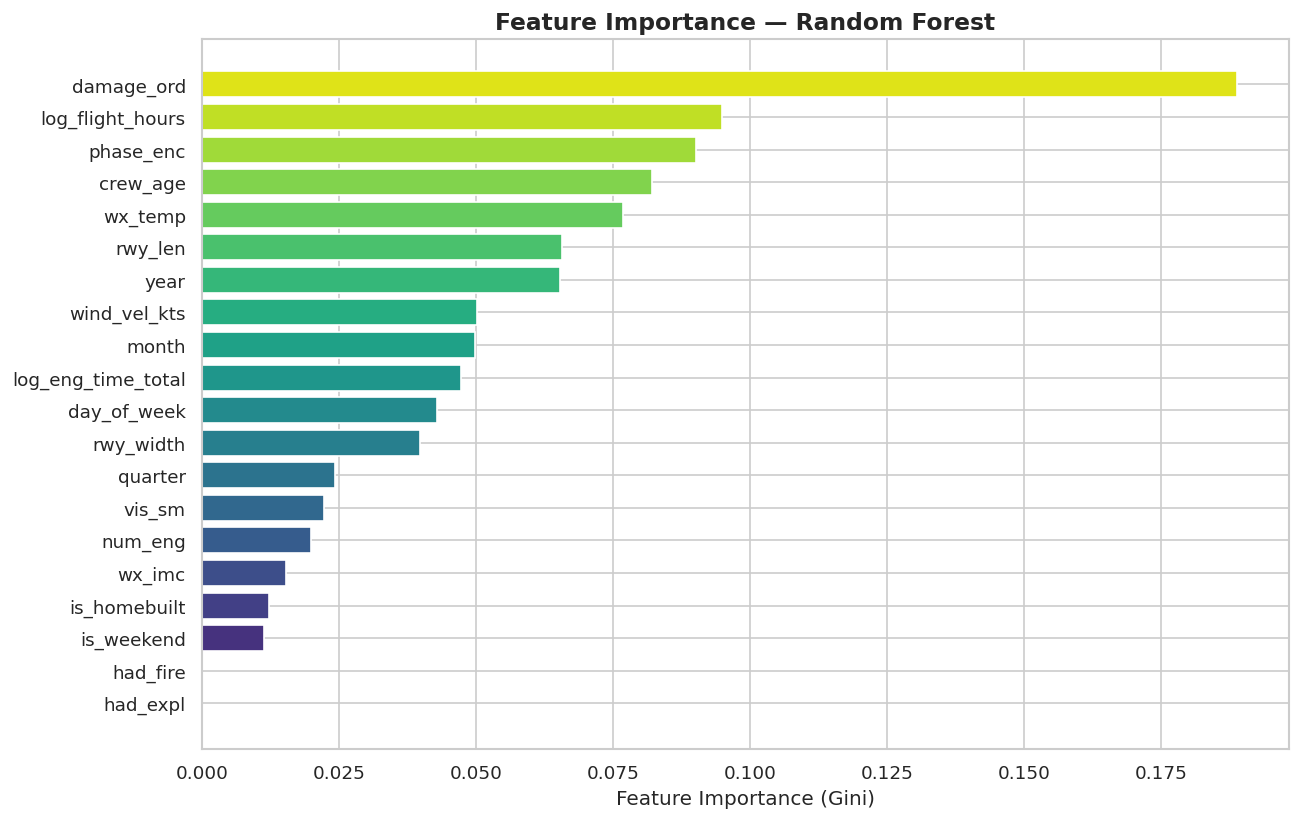


Top 10 Most Important Features:
damage_ord            0.188905
log_flight_hours      0.094926
phase_enc             0.090238
crew_age              0.082092
wx_temp               0.076852
rwy_len               0.065694
year                  0.065339
wind_vel_kts          0.050310
month                 0.049927
log_eng_time_total    0.047374


In [ ]:
# Feature Importance Plot 
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=FEATURE_COLS)
    importances = importances.sort_values(ascending=False)
    
    fig, ax = plt.subplots(figsize=(11, 7))
    colors = sns.color_palette('viridis', len(importances))
    ax.barh(importances.index[::-1], importances.values[::-1], color=colors)
    ax.set_xlabel('Feature Importance (Gini)', fontsize=12)
    ax.set_title(f'Feature Importance — {best_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\nTop 10 Most Important Features:")
    print(importances.head(10).to_string())
else:
    print("Selected best model does not expose feature_importances_. "
          "Using Gradient Boosting as fallback.")
    gb_model = results['Gradient Boosting']['model']
    importances = pd.Series(gb_model.feature_importances_, index=FEATURE_COLS)
    importances = importances.sort_values(ascending=False)
    importances.head(10).plot(kind='barh', figsize=(10, 6))
    plt.title('Feature Importance — Gradient Boosting (Fallback)')
    plt.tight_layout()
    plt.show()


Neural Network-MLP Severity Classifier

In [ ]:
# TensorFlow / Keras Imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from sklearn.utils.class_weight import compute_class_weight

print(f"TensorFlow version: {tf.__version__}")

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Class weights for imbalanced target
classes_arr = np.unique(y_train)
cw = compute_class_weight(class_weight='balanced', classes=classes_arr, y=y_train)
class_weight_dict = {int(k): v for k, v in zip(classes_arr, cw)}
print("Class weights:", class_weight_dict)


TensorFlow version: 2.21.0
Class weights: {0: np.float64(0.4711258222999417), 1: np.float64(1.8064335887611749), 2: np.float64(2.195479239425689), 3: np.float64(1.151587624669245)}


In [ ]:
# Build MLP 
def build_mlp(input_dim, num_classes=4, lr=1e-3):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        layers.Dense(256, kernel_initializer='he_normal'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.3),

        layers.Dense(128, kernel_initializer='he_normal'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.3),

        layers.Dense(64, kernel_initializer='he_normal'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.2),

        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

mlp_model = build_mlp(input_dim=X_train_sc.shape[1])
mlp_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,580 (189.77 KB)

 Trainable params: 47,684 (186.27 KB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
# Training MLP 
early_stop_mlp = callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)

reduce_lr_mlp = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1)

history_mlp = mlp_model.fit(
    X_train_sc, y_train,
    validation_split=0.15,
    epochs=100,
    batch_size=256,
    class_weight=class_weight_dict,
    callbacks=[early_stop_mlp, reduce_lr_mlp],
    verbose=1
)
print("\n MLP training complete.")


Epoch 1/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.3363 - loss: 1.4430 - val_accuracy: 0.3661 - val_loss: 1.3282 - learning_rate: 0.0010
Epoch 2/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.3894 - loss: 1.2997 - val_accuracy: 0.4047 - val_loss: 1.2377 - learning_rate: 0.0010
Epoch 3/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.4063 - loss: 1.2597 - val_accuracy: 0.4513 - val_loss: 1.1947 - learning_rate: 0.0010
Epoch 4/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.4165 - loss: 1.2414 - val_accuracy: 0.4560 - val_loss: 1.1881 - learning_rate: 0.0010
Epoch 5/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.4282 - loss: 1.2194 - val_accuracy: 0.4781 - val_loss: 1.1720 - learning_rate: 0.0010
Epoch 6/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4376 - loss: 1.2163 - val_accuracy: 0.4648 - val_loss: 1.1715 - learning_rate: 0.0010
Epoch 7/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4373 - loss: 1.2094 - 

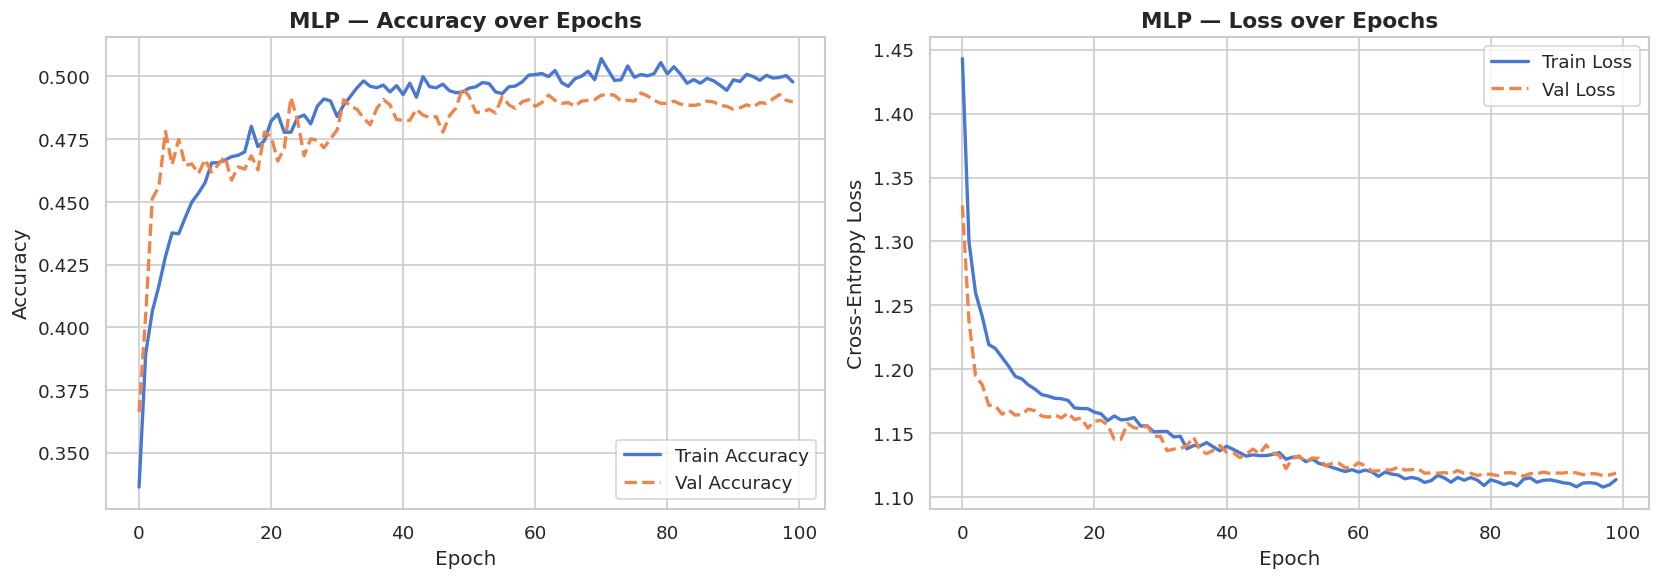

In [ ]:
# Training History Plot 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_mlp.history['accuracy'],     label='Train Accuracy', linewidth=2)
ax1.plot(history_mlp.history['val_accuracy'], label='Val Accuracy',   linewidth=2, linestyle='--')
ax1.set_title('MLP — Accuracy over Epochs', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy'); ax1.legend()

ax2.plot(history_mlp.history['loss'],     label='Train Loss', linewidth=2)
ax2.plot(history_mlp.history['val_loss'], label='Val Loss',   linewidth=2, linestyle='--')
ax2.set_title('MLP — Loss over Epochs', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Cross-Entropy Loss'); ax2.legend()

plt.tight_layout()
plt.show()


177/177 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Classification Report — MLP Neural Network:
              precision    recall  f1-score   support

    None (0)       0.80      0.45      0.58      3003
   Minor (1)       0.21      0.42      0.28       783
 Serious (2)       0.21      0.33      0.26       644
   Fatal (3)       0.61      0.71      0.66      1228

    accuracy                           0.49      5658
   macro avg       0.46      0.48      0.44      5658
weighted avg       0.61      0.49      0.52      5658



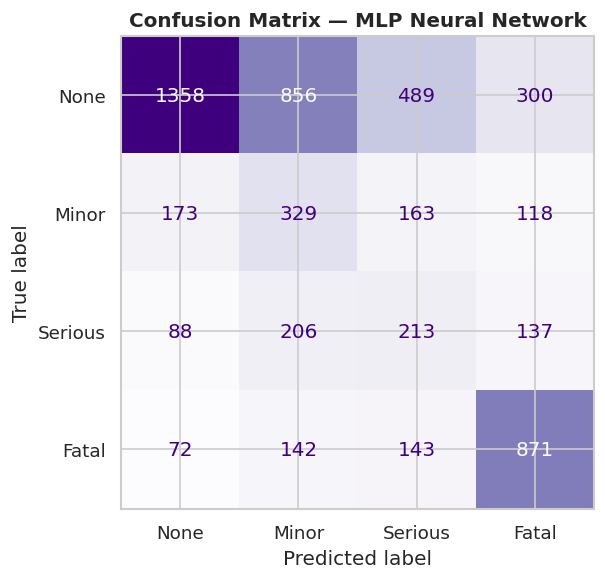

In [ ]:
# MLP Evaluation 
y_pred_mlp_prob = mlp_model.predict(X_test_sc)
y_pred_mlp      = np.argmax(y_pred_mlp_prob, axis=1)

sev_labels = ['None (0)', 'Minor (1)', 'Serious (2)', 'Fatal (3)']
print("Classification Report — MLP Neural Network:")
print(classification_report(y_test, y_pred_mlp, target_names=sev_labels, zero_division=0))

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
ConfusionMatrixDisplay(confusion_matrix=cm_mlp,
                       display_labels=['None','Minor','Serious','Fatal']).plot(
    ax=ax, colorbar=False, cmap='Purples')
ax.set_title('Confusion Matrix — MLP Neural Network', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# MLP ROC Curve & Metrics Summary 
from sklearn.metrics import accuracy_score, f1_score, roc_curve, auc
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])
fpr_mlp, tpr_mlp, _ = roc_curve(y_test_bin[:, 3], y_pred_mlp_prob[:, 3])
roc_auc_mlp = auc(fpr_mlp, tpr_mlp)

mlp_acc = accuracy_score(y_test, y_pred_mlp)
mlp_f1w = f1_score(y_test, y_pred_mlp, average='weighted', zero_division=0)
mlp_f1m = f1_score(y_test, y_pred_mlp, average='macro',    zero_division=0)

print(f"MLP Accuracy   : {mlp_acc:.4f}")
print(f"MLP F1-Weighted: {mlp_f1w:.4f}")
print(f"MLP F1-Macro   : {mlp_f1m:.4f}")
print(f"MLP ROC-AUC (Fatal class): {roc_auc_mlp:.4f}")

# Add to comparison_df
mlp_row = pd.DataFrame([{
    'Model'        : 'MLP Neural Network',
    'CV Accuracy'  : 'N/A (val_split)',
    'Test Accuracy': round(mlp_acc, 4),
    'F1-Weighted'  : round(mlp_f1w, 4),
    'F1-Macro'     : round(mlp_f1m, 4),
}])
comparison_df_full = pd.concat([comparison_df, mlp_row], ignore_index=True)
comparison_df_full = comparison_df_full.sort_values('Test Accuracy', ascending=False)
print("\nUpdated Model Comparison (including MLP):")
print(comparison_df_full.to_string(index=False))


MLP Accuracy   : 0.4897
MLP F1-Weighted: 0.5182
MLP F1-Macro   : 0.4442
MLP ROC-AUC (Fatal class): 0.8683

Updated Model Comparison (including MLP):
              Model     CV Accuracy  Test Accuracy  F1-Weighted  F1-Macro
      Random Forest 0.5582 ± 0.0068         0.5650       0.5819    0.4820
  Gradient Boosting 0.6492 ± 0.0019         0.5527       0.5745    0.4799
            XGBoost 0.6498 ± 0.0032         0.5504       0.5738    0.4780
 MLP Neural Network N/A (val_split)         0.4897       0.5182    0.4442
      Decision Tree 0.4728 ± 0.0066         0.4721       0.5061    0.4293
Logistic Regression 0.4371 ± 0.0084         0.4445       0.4631    0.4016


Time_Series Forecasting

In [ ]:
# Building Monthly Time Series 
ts = (df.groupby('year_month')['ev_id']
      .count()
      .reset_index())
ts.columns = ['period', 'accident_count']
ts['ds'] = ts['period'].dt.to_timestamp()

# Exclude incomplete months (partial 2025 data)
ts = ts[ts['ds'] < pd.Timestamp('2025-01-01')].copy()
ts.set_index('ds', inplace=True)
ts.index = pd.DatetimeIndex(ts.index, freq='MS')

print(f"Time series: {ts.index.min().date()} → {ts.index.max().date()}")
print(f"Length: {len(ts)} monthly observations")
ts['accident_count'].describe()


Time series: 2008-01-01 → 2024-12-01
Length: 204 monthly observations


count    204.000000
mean     141.705882
std       40.925762
min       74.000000
25%      108.750000
50%      140.000000
75%      172.250000
max      249.000000
Name: accident_count, dtype: float64

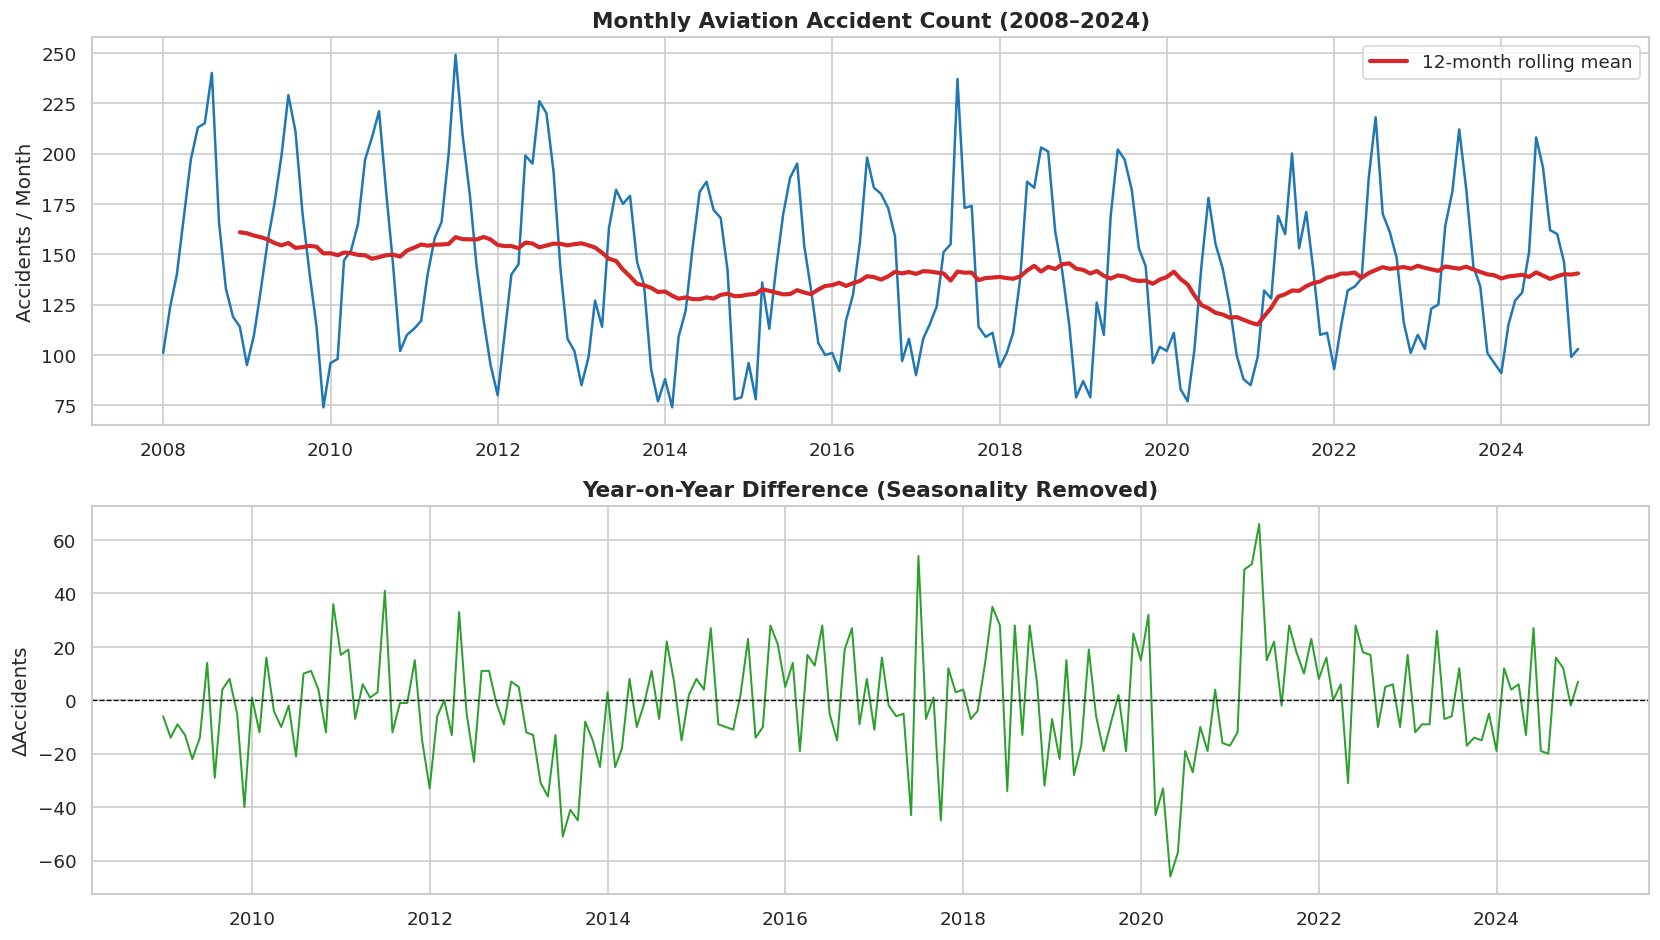

In [ ]:
# Time-Series Visualisation 
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

ax1.plot(ts.index, ts['accident_count'], linewidth=1.5, color=PALETTE[0])
ax1.set_title('Monthly Aviation Accident Count (2008–2024)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Accidents / Month')

# 12-month rolling mean
roll12 = ts['accident_count'].rolling(12).mean()
ax1.plot(ts.index, roll12, linewidth=2.5, color='#d62728',
         label='12-month rolling mean')
ax1.legend()

# FIX: use diff12.index instead of ts.index to match the shorter length
diff12 = ts['accident_count'].diff(12).dropna()
ax2.plot(diff12.index, diff12,
         linewidth=1.2, color=PALETTE[2])
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_title('Year-on-Year Difference (Seasonality Removed)', fontsize=13, fontweight='bold')
ax2.set_ylabel('ΔAccidents')

plt.tight_layout()
plt.show()

In [ ]:
# Stationarity Test (ADF)
def adf_test(series, title='Series'):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f"ADF Test — {title}")
    print(f"  ADF Statistic : {result[0]:.4f}")
    print(f"  p-value       : {result[1]:.4f}")
    print(f"  Stationary?   : {'YES ✅' if result[1] < 0.05 else 'NO ❌'}")
    print()

adf_test(ts['accident_count'],         'Original Series')
adf_test(ts['accident_count'].diff(1).dropna(),  '1st Difference')
adf_test(ts['accident_count'].diff(12).dropna(), 'Seasonal Difference (12)')


ADF Test — Original Series
  ADF Statistic : -2.4105
  p-value       : 0.1388
  Stationary?   : NO ❌

ADF Test — 1st Difference
  ADF Statistic : -4.5403
  p-value       : 0.0002
  Stationary?   : YES ✅

ADF Test — Seasonal Difference (12)
  ADF Statistic : -2.7371
  p-value       : 0.0678
  Stationary?   : NO ❌



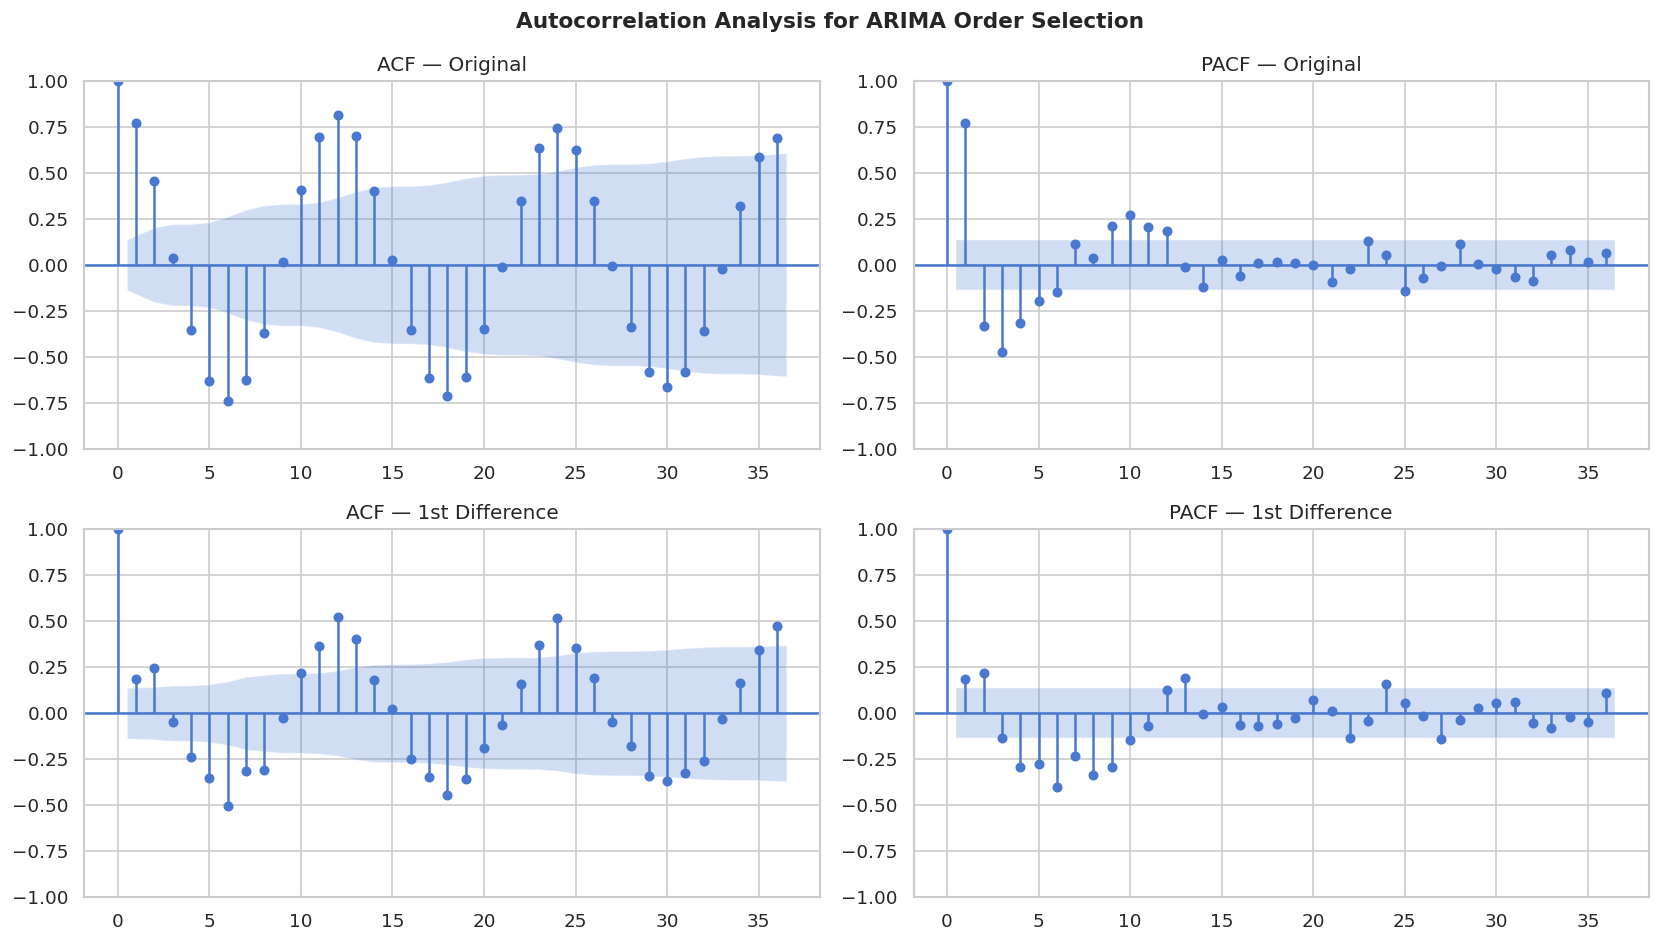

In [ ]:
# ACF / PACF Plots 
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plot_acf(ts['accident_count'], lags=36, ax=axes[0, 0])
axes[0, 0].set_title('ACF — Original')

plot_pacf(ts['accident_count'], lags=36, ax=axes[0, 1], method='ywm')
axes[0, 1].set_title('PACF — Original')

plot_acf(ts['accident_count'].diff(1).dropna(), lags=36, ax=axes[1, 0])
axes[1, 0].set_title('ACF — 1st Difference')

plot_pacf(ts['accident_count'].diff(1).dropna(), lags=36, ax=axes[1, 1], method='ywm')
axes[1, 1].set_title('PACF — 1st Difference')

plt.suptitle('Autocorrelation Analysis for ARIMA Order Selection',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# Train / Test Split for Time Series 
FORECAST_HORIZON = 24   # months to hold out for evaluation

ts_train = ts.iloc[:-FORECAST_HORIZON]
ts_test  = ts.iloc[-FORECAST_HORIZON:]

print(f"Train: {ts_train.index[0].date()} → {ts_train.index[-1].date()} ({len(ts_train)} obs)")
print(f"Test : {ts_test.index[0].date()} → {ts_test.index[-1].date()} ({len(ts_test)} obs)")


Train: 2008-01-01 → 2022-12-01 (180 obs)
Test : 2023-01-01 → 2024-12-01 (24 obs)


In [ ]:
# Evaluation function for time-series forecasts 
def ts_metrics(actual, predicted, model_name):
    mae  = mean_absolute_error(actual, predicted)
    rmse = sqrt(np.mean((np.array(actual) - np.array(predicted))**2))
    mape = np.mean(np.abs((np.array(actual) - np.array(predicted)) /
                           np.array(actual))) * 100
    print(f"[{model_name}]  MAE={mae:.2f}  RMSE={rmse:.2f}  MAPE={mape:.2f}%")
    return {'Model': model_name, 'MAE': round(mae, 2),
            'RMSE': round(rmse, 2), 'MAPE': round(mape, 2)}

ts_results = []


In [ ]:
# ARIMA Model 
print("Fitting ARIMA(2,1,2)...")
arima_model = ARIMA(ts_train['accident_count'], order=(2, 1, 2))
arima_fit   = arima_model.fit()
arima_fc    = arima_fit.forecast(steps=FORECAST_HORIZON)

print(arima_fit.summary().tables[0])
ts_results.append(ts_metrics(ts_test['accident_count'].values, arima_fc.values, 'ARIMA(2,1,2)'))


Fitting ARIMA(2,1,2)...
                               SARIMAX Results                                
Dep. Variable:         accident_count   No. Observations:                  180
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -793.218
Date:                Mon, 08 Jun 2026   AIC                           1596.436
Time:                        22:41:09   BIC                           1612.373
Sample:                    01-01-2008   HQIC                          1602.898
                         - 12-01-2022                                         
Covariance Type:                  opg                                         
[ARIMA(2,1,2)]  MAE=15.85  RMSE=20.89  MAPE=11.54%


In [ ]:
# SARIMA Model
print("Fitting SARIMA(1,1,1)(1,1,1,12)...")
sarima_model = SARIMAX(ts_train['accident_count'],
                       order=(1, 1, 1),
                       seasonal_order=(1, 1, 1, 12),
                       enforce_stationarity=False,
                       enforce_invertibility=False)
sarima_fit = sarima_model.fit(disp=False)
sarima_fc  = sarima_fit.forecast(steps=FORECAST_HORIZON)

ts_results.append(ts_metrics(ts_test['accident_count'].values, sarima_fc.values, 'SARIMA(1,1,1)(1,1,1,12)'))


Fitting SARIMA(1,1,1)(1,1,1,12)...
[SARIMA(1,1,1)(1,1,1,12)]  MAE=8.40  RMSE=10.93  MAPE=6.20%


In [ ]:
# Prophet Model
if PROPHET_AVAILABLE:
    prophet_df = ts_train.reset_index()[['ds', 'accident_count']].rename(
        columns={'accident_count': 'y'})
    
    prophet_model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_prior_scale=0.3
    )
    prophet_model.fit(prophet_df)
    
    future = prophet_model.make_future_dataframe(periods=FORECAST_HORIZON, freq='MS')
    prophet_fc_full = prophet_model.predict(future)
    prophet_fc = prophet_fc_full.tail(FORECAST_HORIZON)['yhat'].values
    
    ts_results.append(ts_metrics(ts_test['accident_count'].values, prophet_fc, 'Prophet'))
else:
    print("Prophet not available — skipping.")
    prophet_fc = None


22:41:23 - cmdstanpy - INFO - Chain [1] start processing
22:41:24 - cmdstanpy - INFO - Chain [1] done processing


[Prophet]  MAE=10.59  RMSE=13.42  MAPE=7.62%


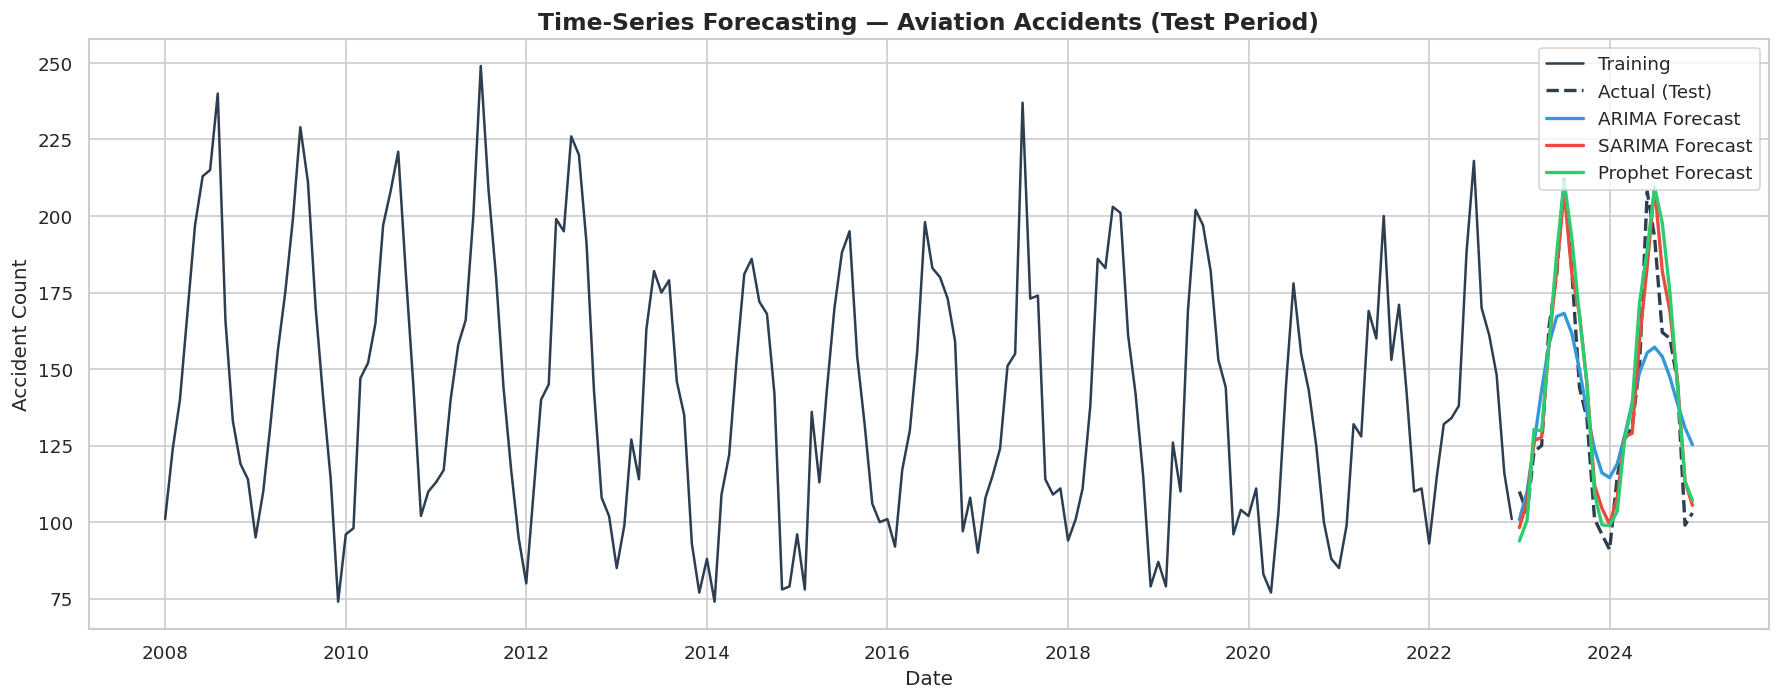

In [ ]:
# Forecast Visualisation
fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(ts_train.index, ts_train['accident_count'],
        label='Training', color='#2c3e50', linewidth=1.5)
ax.plot(ts_test.index, ts_test['accident_count'],
        label='Actual (Test)', color='#2c3e50', linewidth=2, linestyle='--')

ax.plot(ts_test.index, arima_fc.values,
        label='ARIMA Forecast', color='#3498db', linewidth=2)
ax.plot(ts_test.index, sarima_fc.values,
        label='SARIMA Forecast', color='#e74c3c', linewidth=2)

if PROPHET_AVAILABLE and prophet_fc is not None:
    ax.plot(ts_test.index, prophet_fc,
            label='Prophet Forecast', color='#2ecc71', linewidth=2)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Accident Count', fontsize=12)
ax.set_title('Time-Series Forecasting — Aviation Accidents (Test Period)',
             fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


Generating 18-month future forecast with SARIMA...


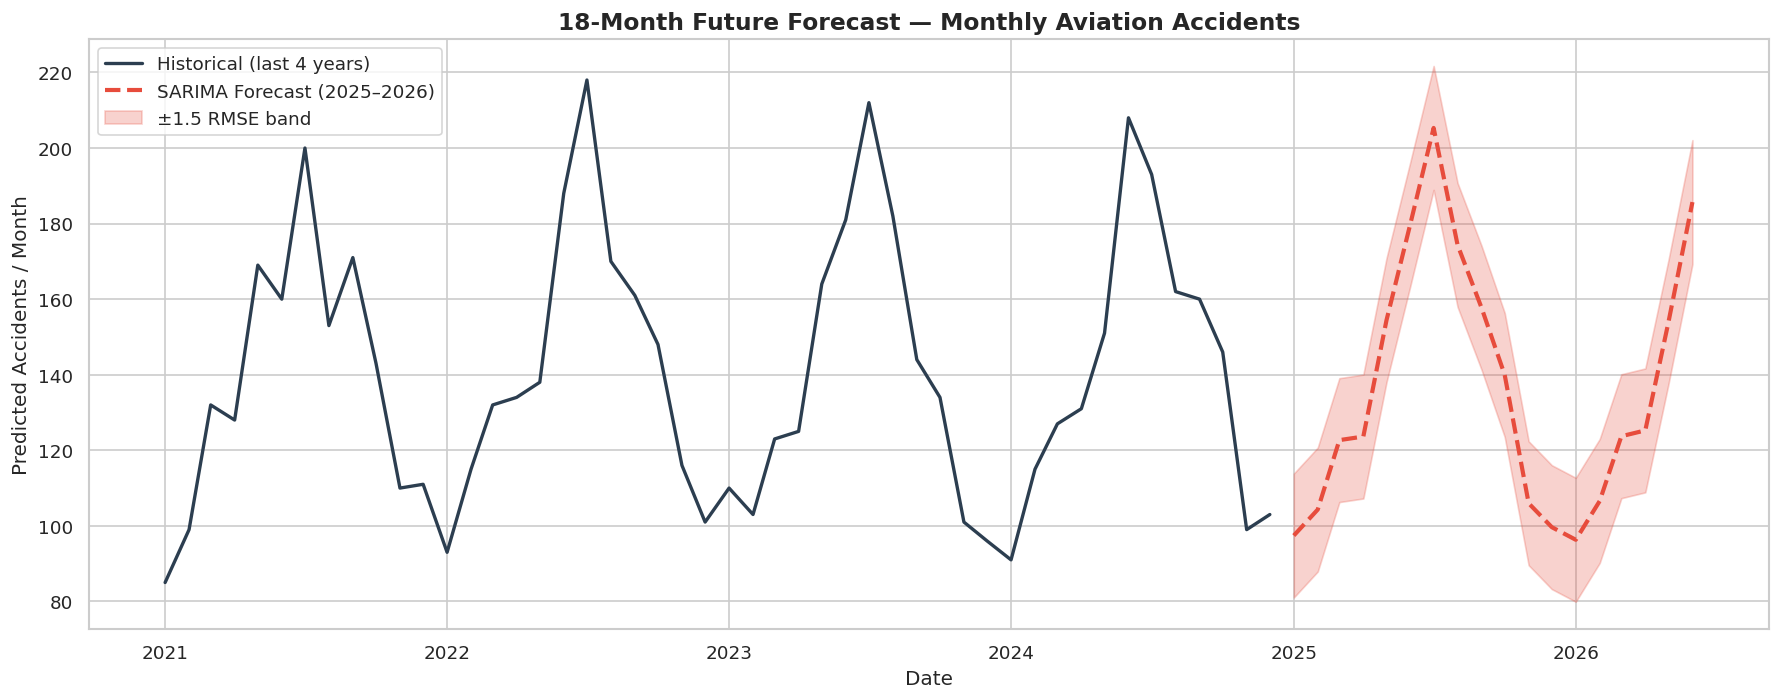

In [ ]:
# Future Forecast (2025–2026) 
print("Generating 18-month future forecast with SARIMA...")
sarima_full = SARIMAX(ts['accident_count'],
                      order=(1, 1, 1),
                      seasonal_order=(1, 1, 1, 12),
                      enforce_stationarity=False,
                      enforce_invertibility=False).fit(disp=False)

future_steps = 18
sarima_future = sarima_full.forecast(steps=future_steps)
future_idx = pd.date_range(ts.index[-1] + pd.DateOffset(months=1),
                           periods=future_steps, freq='MS')

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(ts.index[-48:], ts['accident_count'].iloc[-48:],
        label='Historical (last 4 years)', color='#2c3e50', linewidth=2)
ax.plot(future_idx, sarima_future.values,
        label='SARIMA Forecast (2025–2026)', color='#e74c3c',
        linewidth=2.5, linestyle='--')

# Confidence interval (approx ±1 RMSE from test)
best_rmse = min(r['RMSE'] for r in ts_results)
ax.fill_between(future_idx,
                sarima_future.values - 1.5 * best_rmse,
                sarima_future.values + 1.5 * best_rmse,
                alpha=0.25, color='#e74c3c', label='±1.5 RMSE band')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Predicted Accidents / Month', fontsize=12)
ax.set_title('18-Month Future Forecast — Monthly Aviation Accidents',
             fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Forecasting Model Comparison
ts_comparison = pd.DataFrame(ts_results).sort_values('MAPE')
print("\nForecasting Model Comparison:")
print(ts_comparison.to_string(index=False))



Forecasting Model Comparison:
                  Model   MAE  RMSE  MAPE
SARIMA(1,1,1)(1,1,1,12)  8.40 10.93  6.20
                Prophet 10.59 13.42  7.62
           ARIMA(2,1,2) 15.85 20.89 11.54


Neural Network-LSTM Time_Series Forecasting 

In [ ]:
# LSTM Data Preparation 
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers as klayers

tf.random.set_seed(42)

# MinMax normalise the full series
series_values = ts['accident_count'].values.astype(float)
ts_min_v, ts_max_v = series_values.min(), series_values.max()
series_norm = (series_values - ts_min_v) / (ts_max_v - ts_min_v)

LOOKBACK = 12  # 12-month input window

def make_sequences(data, lookback):
    Xs, ys = [], []
    for i in range(len(data) - lookback):
        Xs.append(data[i : i + lookback])
        ys.append(data[i + lookback])
    return np.array(Xs), np.array(ys)

X_seq_all, y_seq_all = make_sequences(series_norm, LOOKBACK)

split_idx = len(X_seq_all) - FORECAST_HORIZON
X_tr_lstm = X_seq_all[:split_idx].reshape(-1, LOOKBACK, 1)
X_te_lstm = X_seq_all[split_idx:].reshape(-1, LOOKBACK, 1)
y_tr_lstm = y_seq_all[:split_idx]
y_te_lstm = y_seq_all[split_idx:]

print(f"LSTM train: {X_tr_lstm.shape}  |  test: {X_te_lstm.shape}")


LSTM train: (168, 12, 1)  |  test: (24, 12, 1)


In [ ]:
# Build Stacked LSTM 
def build_lstm(lookback, lr=1e-3):
    model = keras.Sequential([
        klayers.Input(shape=(lookback, 1)),

        klayers.LSTM(64, return_sequences=True),
        klayers.Dropout(0.2),

        klayers.LSTM(32, return_sequences=False),
        klayers.Dropout(0.2),

        klayers.Dense(16, activation='relu'),
        klayers.Dense(1)   # single-step regression output
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='mse',
        metrics=['mae']
    )
    return model

lstm_model = build_lstm(LOOKBACK)
lstm_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

In [67]:
# ── Train LSTM ────────────────────────────────────────────────────────────────
lstm_es = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=20, restore_best_weights=True, verbose=1)

history_lstm = lstm_model.fit(
    X_tr_lstm, y_tr_lstm,
    validation_split=0.15,
    epochs=150,
    batch_size=16,
    callbacks=[lstm_es],
    verbose=1
)
print("\n LSTM training complete.")


Epoch 1/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - loss: 0.0127 - mae: 0.0886 - val_loss: 0.0107 - val_mae: 0.0822
Epoch 2/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.0111 - mae: 0.0844 - val_loss: 0.0136 - val_mae: 0.0918
Epoch 3/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0131 - mae: 0.0850 - val_loss: 0.0135 - val_mae: 0.0925
Epoch 4/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0108 - mae: 0.0831 - val_loss: 0.0129 - val_mae: 0.0937
Epoch 5/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0113 - mae: 0.0822 - val_loss: 0.0140 - val_mae: 0.0954
Epoch 6/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0123 - mae: 0.0845 - val_loss: 0.0139 - val_mae: 0.0936
Epoch 7/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0148 - mae: 0.0902 - val_loss: 0.0111 - val_mae: 0.0842
Epoch 8/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0122 - mae: 0.0860 - val_loss: 0.0152 - val_mae: 0.0980
Epoch 9/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0127 - mae: 

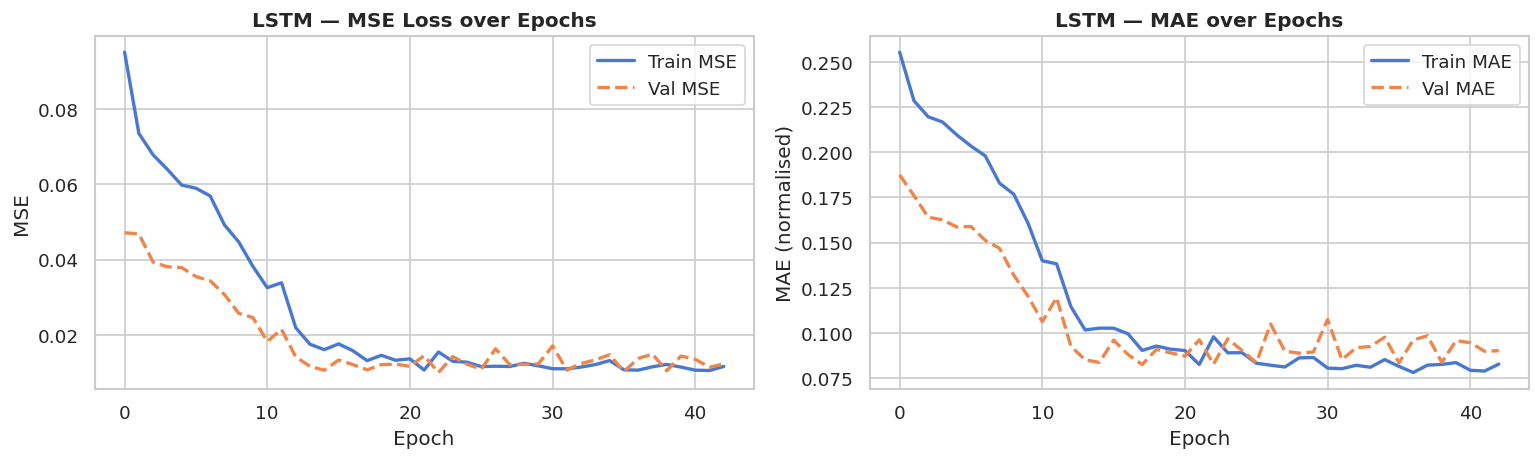

In [ ]:
# LSTM Training History
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(history_lstm.history['loss'],     label='Train MSE', linewidth=2)
ax1.plot(history_lstm.history['val_loss'], label='Val MSE',   linewidth=2, linestyle='--')
ax1.set_title('LSTM — MSE Loss over Epochs', fontsize=12, fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('MSE'); ax1.legend()

ax2.plot(history_lstm.history['mae'],     label='Train MAE', linewidth=2)
ax2.plot(history_lstm.history['val_mae'], label='Val MAE',   linewidth=2, linestyle='--')
ax2.set_title('LSTM — MAE over Epochs', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('MAE (normalised)'); ax2.legend()

plt.tight_layout()
plt.show()


In [ ]:
# LSTM Predictions — Denormalise & Evaluate
from math import sqrt
from sklearn.metrics import mean_absolute_error

lstm_pred_norm  = lstm_model.predict(X_te_lstm).flatten()
lstm_pred       = lstm_pred_norm  * (ts_max_v - ts_min_v) + ts_min_v
lstm_actual_den = y_te_lstm       * (ts_max_v - ts_min_v) + ts_min_v

lstm_mae  = mean_absolute_error(lstm_actual_den, lstm_pred)
lstm_rmse = sqrt(((lstm_actual_den - lstm_pred) ** 2).mean())
lstm_mape = (abs((lstm_actual_den - lstm_pred) / lstm_actual_den) * 100).mean()

print(f"[LSTM]  MAE={lstm_mae:.2f}  RMSE={lstm_rmse:.2f}  MAPE={lstm_mape:.2f}%")
ts_results.append({'Model': 'LSTM', 'MAE': round(lstm_mae, 2),
                   'RMSE': round(lstm_rmse, 2), 'MAPE': round(lstm_mape, 2)})


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 928ms/step
[LSTM]  MAE=10.35  RMSE=12.15  MAPE=7.62%


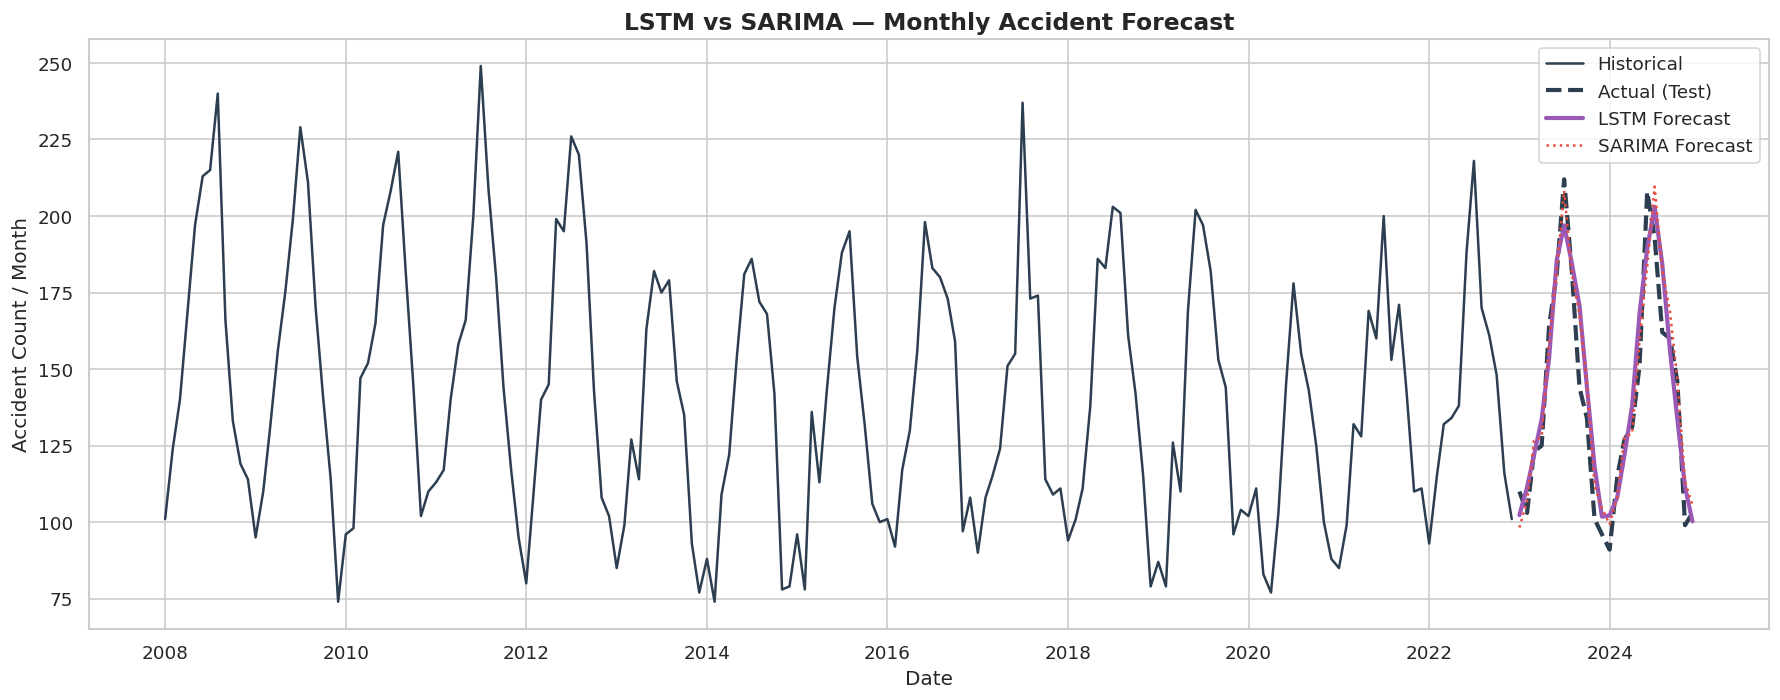

In [ ]:
# LSTM Forecast Visualisation
test_dates = ts.index[-FORECAST_HORIZON:]

fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(ts.index[:-FORECAST_HORIZON], ts['accident_count'].iloc[:-FORECAST_HORIZON],
        label='Historical', color='#2c3e50', linewidth=1.5)
ax.plot(test_dates, lstm_actual_den,
        label='Actual (Test)', color='#2c3e50', linewidth=2.5, linestyle='--')
ax.plot(test_dates, lstm_pred,
        label='LSTM Forecast', color='#9b59b6', linewidth=2.5)
ax.plot(test_dates, sarima_fc.values,
        label='SARIMA Forecast', color='#e74c3c', linewidth=1.5, linestyle=':')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Accident Count / Month', fontsize=12)
ax.set_title('LSTM vs SARIMA — Monthly Accident Forecast',
             fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


Final Forecasting Comparison:
                     Model    MAE   RMSE   MAPE
1  SARIMA(1,1,1)(1,1,1,12)   8.40  10.93   6.20
2                  Prophet  10.59  13.42   7.62
3                     LSTM  10.35  12.15   7.62
4             ARIMA(2,1,2)  15.85  20.89  11.54


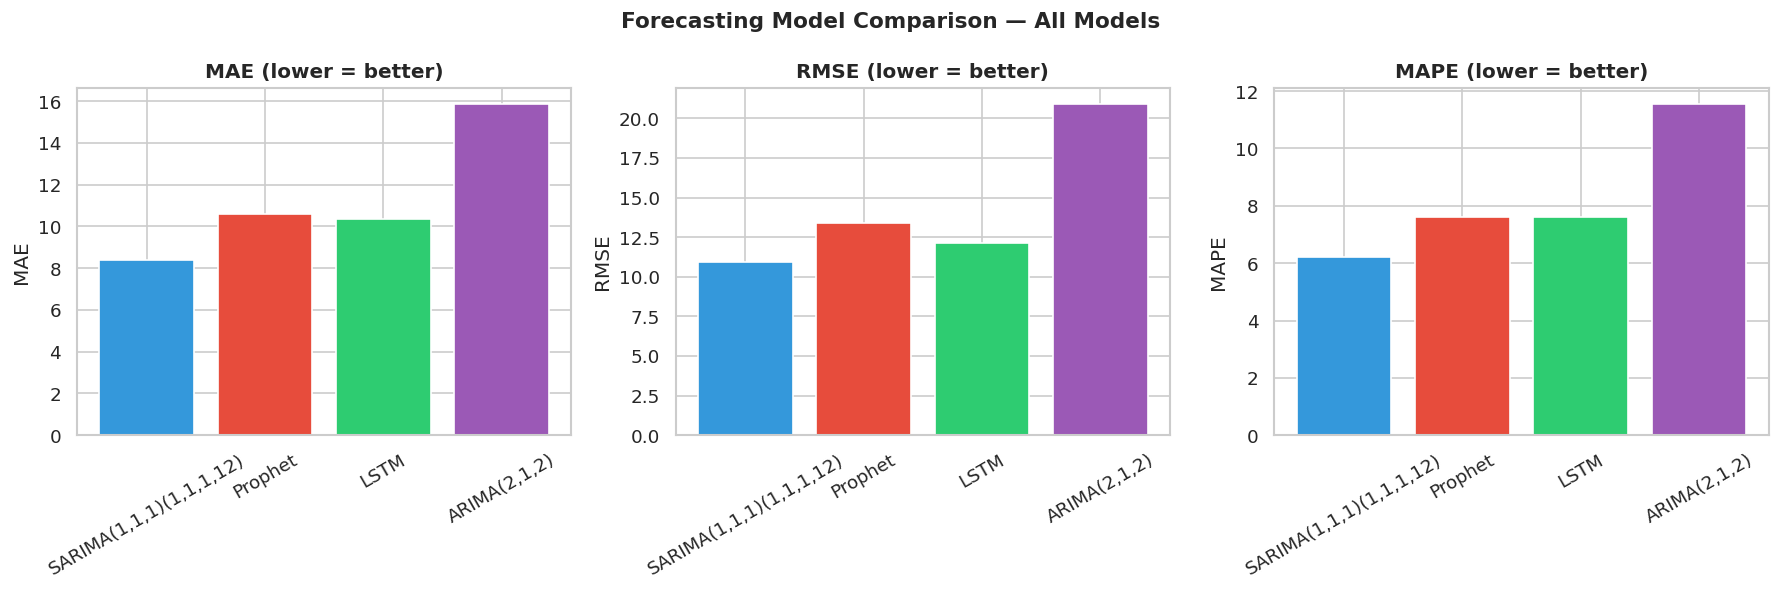

In [ ]:
# Final Forecasting Model Comparison (ARIMA + SARIMA + Prophet + LSTM) 
ts_final = pd.DataFrame(ts_results).sort_values('MAPE').reset_index(drop=True)
ts_final.index += 1
print("Final Forecasting Comparison:")
print(ts_final.to_string())

# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors_ts  = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6',
               '#f39c12', '#1abc9c'][:len(ts_final)]

for ax, metric in zip(axes, ['MAE', 'RMSE', 'MAPE']):
    ax.bar(ts_final['Model'], ts_final[metric], color=colors_ts, edgecolor='white')
    ax.set_title(f'{metric} (lower = better)', fontsize=12, fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Forecasting Model Comparison — All Models',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
